# Discrete-Memory GRU Pipeline for the Asymmetric Process

This notebook implements the same end-to-end data-driven epsilon-machine extraction and quantum-compression pipeline, now specialised to the **asymmetric process** shown in the reference figure.

The pipeline is unchanged in structure:

- a **continuous encoder GRU** processes the past,
- a **hard straight-through Gumbel-Softmax** discrete memory state is introduced at the past-future boundary,
- a **learned continuous embedding** of that discrete state is used for
  - next-symbol emission, and
  - next discrete-state transition,
- a **raw symbolic machine** is extracted from the trained neural model,
- symbolically similar latent states are **merged by future-distribution similarity**,
- the resulting machine is then **quantum compressed** via the q-simulator construction.

The only process-level changes made are those required to replace the asymmetric-process-process generator, exact benchmark, and process-specific diagnostics with the asymmetric process.


In [1]:

import os
import math
import random
import copy
from dataclasses import dataclass, asdict
from collections import defaultdict, Counter
from typing import Dict, List, Tuple, Optional

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
    torch.set_num_threads(max(1, min(8, (os.cpu_count() or 2) // 2)))

print(f"Using device: {DEVICE}")
print(f"Torch version: {torch.__version__}")

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


Using device: cuda
Torch version: 2.9.0+cu128


In [2]:

@dataclass
class ExperimentConfig:
    # --- Asymmetric-process parameters ---
    asym_p: float = 0.70
    asym_q: float = 0.80

    # --- Data ---
    total_symbols: int = 30_000
    train_frac: float = 0.85
    val_frac: float = 0.10

    past_len: int = 20
    future_len: int = 10

    # --- Model ---
    num_states: int = 12
    symbol_vocab_size: int = 3
    symbol_embed_dim: int = 8
    memory_dim: int = 32
    encoder_hidden_dim: int = 32

    # --- Training ---
    batch_size: int = 128
    max_epochs: int = 150
    learning_rate: float = 1e-3
    lr_min: float = 1e-5
    weight_decay: float = 5e-4
    det_weight: float = 0.0000
    tau_start: float = 2.25
    tau_end: float = 0.1
    grad_clip: float = 1.0

    # --- Merge ---
    merge_future_horizon: int = 10
    merge_js_threshold: float = 0.001
    min_state_count_for_merge: int = 35

    # --- Display ---
    print_every: int = 2
    show_batch_progress: bool = False

    random_seed: int = 7

cfg = ExperimentConfig()
set_seed(cfg.random_seed)

# Keep the same overall training pipeline; only the process model changes.
cfg.memory_dim = max(32, cfg.num_states)
cfg.encoder_hidden_dim = cfg.memory_dim

print("Experiment configuration:")
print(pd.Series(asdict(cfg)))


Experiment configuration:
asym_p                           0.7
asym_q                           0.8
total_symbols                  30000
train_frac                      0.85
val_frac                         0.1
past_len                          20
future_len                        10
num_states                        12
symbol_vocab_size                  3
symbol_embed_dim                   8
memory_dim                        32
encoder_hidden_dim                32
batch_size                       128
max_epochs                       150
learning_rate                  0.001
lr_min                       0.00001
weight_decay                  0.0005
det_weight                       0.0
tau_start                       2.25
tau_end                          0.1
grad_clip                        1.0
merge_future_horizon              10
merge_js_threshold             0.001
min_state_count_for_merge         35
print_every                        2
show_batch_progress            False
random_seed 

In [3]:

def _stationary_distribution_for_machine(machine: Dict[str, np.ndarray]) -> np.ndarray:
    next_state = np.asarray(machine["next_state"], dtype=np.int64)
    emission_probs = np.asarray(machine["emission_probs"], dtype=np.float64)
    num_states = next_state.shape[0]

    T = np.zeros((num_states, num_states), dtype=np.float64)
    for s in range(num_states):
        for x in range(emission_probs.shape[1]):
            T[s, int(next_state[s, x])] += float(emission_probs[s, x])

    A = T.T - np.eye(num_states)
    A[-1, :] = 1.0
    b = np.zeros(num_states, dtype=np.float64)
    b[-1] = 1.0
    pi = np.linalg.solve(A, b)
    pi = np.clip(pi, 0.0, None)
    pi /= max(pi.sum(), 1e-12)
    return pi

def true_asymmetric_machine(p: float, q: float) -> Dict[str, np.ndarray]:
    """Three-state asymmetric process from Binder, Thompson & Gu (2018), Fig. 3.

    States are ordered as:
        0 -> s0
        1 -> s1
        2 -> s2

    Symbol alphabet is {0, 1, 2}, with transitions
        s0 --0|(1-p)--> s0,   s0 --2|p--> s2
        s1 --1|(1-q)--> s1,   s1 --0|q(1-p)--> s0,   s1 --2|pq--> s2
        s2 --1|1--> s1

    For zero-probability symbols, the next-state entry is chosen consistently with
    the synchronising-symbol interpretation:
        symbol 0 -> s0, symbol 1 -> s1, symbol 2 -> s2.
    Those entries are never used under exact generation because their emission
    probabilities are zero.
    """
    if not (0.0 < p < 1.0 and 0.0 < q < 1.0):
        raise ValueError("Parameters p and q must lie strictly between 0 and 1.")

    next_state = np.array([
        [0, 1, 2],  # from s0
        [0, 1, 2],  # from s1
        [0, 1, 2],  # from s2
    ], dtype=np.int64)

    emission_probs = np.array([
        [1.0 - p,       0.0,     p      ],   # s0
        [q * (1.0 - p), 1.0 - q, p * q  ],   # s1
        [0.0,           1.0,     0.0    ],   # s2
    ], dtype=np.float64)

    return {"next_state": next_state, "emission_probs": emission_probs}

def asymmetric_stationary_distribution(p: float, q: float) -> np.ndarray:
    return _stationary_distribution_for_machine(true_asymmetric_machine(p, q))

def simulate_asymmetric_process(p: float, q: float, total_symbols: int, seed: int = 0) -> Tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    machine = true_asymmetric_machine(p, q)
    stationary = asymmetric_stationary_distribution(p, q)

    num_states = machine["next_state"].shape[0]
    vocab_size = machine["emission_probs"].shape[1]

    state = int(rng.choice(num_states, p=stationary))
    symbols = np.zeros(total_symbols, dtype=np.int64)
    states = np.zeros(total_symbols, dtype=np.int64)

    for t in range(total_symbols):
        states[t] = state
        x = int(rng.choice(vocab_size, p=machine["emission_probs"][state]))
        symbols[t] = x
        state = int(machine["next_state"][state, x])

    return symbols, states

def contiguous_symbol_splits(sequence: np.ndarray, train_frac: float, val_frac: float):
    n = len(sequence)
    train_end = int(train_frac * n)
    val_end = int((train_frac + val_frac) * n)
    return sequence[:train_end], sequence[train_end:val_end], sequence[val_end:]

def make_windows(sequence: np.ndarray, past_len: int, future_len: int) -> Tuple[np.ndarray, np.ndarray]:
    total = len(sequence) - past_len - future_len + 1
    if total <= 0:
        raise ValueError("Split is too short for the chosen past/future lengths.")
    past = np.stack([sequence[i : i + past_len] for i in range(total)])
    future = np.stack([sequence[i + past_len : i + past_len + future_len] for i in range(total)])
    return past, future

class WindowDataset(Dataset):
    def __init__(self, past: np.ndarray, future: np.ndarray):
        self.past = torch.as_tensor(past, dtype=torch.long)
        self.future = torch.as_tensor(future, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.past)

    def __getitem__(self, idx: int):
        return self.past[idx], self.future[idx]


In [4]:

class EmbeddedDiscreteMemoryGRU(nn.Module):
    # v2 architecture:
    #   encoder_cell:    continuous GRU that processes the past (no discretization).
    #   encoder_head:    projects encoder hidden state to discrete-state logits at boundary.
    #   transition_cell: discrete GRU that processes future symbols (Gumbel-Softmax each step).
    #   transition_head: projects transition proposal to discrete-state logits.
    #   emission_head:   linear projection from state embedding to symbol logits.
    #   state_emb:       learned embedding table for discrete states.
    #
    # The encoder_cell is used ONLY during training (sequence_objective) and
    # window-end-state inference. Machine extraction and rollout use only
    # transition_cell + state_emb.

    def __init__(self, cfg: ExperimentConfig):
        super().__init__()
        self.cfg = cfg

        self.symbol_emb = nn.Embedding(cfg.symbol_vocab_size, cfg.symbol_embed_dim)
        self.state_emb = nn.Embedding(cfg.num_states, cfg.memory_dim)

        # Continuous encoder for past processing (no discretization per step).
        self.encoder_cell = nn.GRUCell(cfg.symbol_embed_dim, cfg.encoder_hidden_dim)
        self.encoder_head = nn.Linear(cfg.encoder_hidden_dim, cfg.num_states)

        # Discrete transition cell for future processing.
        self.transition_cell = nn.GRUCell(cfg.symbol_embed_dim, cfg.memory_dim)
        self.transition_head = nn.Linear(cfg.memory_dim, cfg.num_states)

        # Linear emission head: discrete state -> symbol logits.
        # No hidden layer: forces all predictive information through the discrete bottleneck.
        self.emission_head = nn.Linear(cfg.memory_dim, cfg.symbol_vocab_size)

        self.init_logits = nn.Parameter(torch.zeros(cfg.num_states))

    # --- Encoder (past processing) ---

    def encode_past(self, past, tau, training_mode):
        batch_size = past.shape[0]
        h = torch.zeros(batch_size, self.cfg.encoder_hidden_dim, device=past.device)

        for t in range(past.shape[1]):
            symbol_vec = self.symbol_emb(past[:, t])
            h = self.encoder_cell(symbol_vec, h)

        logits = self.encoder_head(h)
        if training_mode:
            onehot = F.gumbel_softmax(logits, tau=tau, hard=True, dim=-1)
        else:
            idx = logits.argmax(dim=-1)
            onehot = F.one_hot(idx, num_classes=self.cfg.num_states).float()

        idx = onehot.argmax(dim=-1)
        memory = onehot @ self.state_emb.weight
        return {"idx": idx, "onehot": onehot, "memory": memory, "logits": logits}

    # --- Discrete transition (future processing and extraction) ---

    def next_state_from_memory_and_symbol(self, memory, symbols, tau, training_mode):
        symbol_vec = self.symbol_emb(symbols)
        proposal = self.transition_cell(symbol_vec, memory)
        logits = self.transition_head(proposal)
        if training_mode:
            onehot = F.gumbel_softmax(logits, tau=tau, hard=True, dim=-1)
        else:
            idx = logits.argmax(dim=-1)
            onehot = F.one_hot(idx, num_classes=self.cfg.num_states).float()
        idx = onehot.argmax(dim=-1)
        next_memory = onehot @ self.state_emb.weight
        return {"proposal": proposal, "logits": logits, "idx": idx, "onehot": onehot, "memory": next_memory}

    # --- Emission ---

    def emission_logits_from_memory(self, memory):
        return self.emission_head(memory)


In [5]:

def entropy_from_logits(logits: torch.Tensor) -> torch.Tensor:
    probs = F.softmax(logits, dim=-1)
    return -(probs * F.log_softmax(logits, dim=-1)).sum(dim=-1)

def sequence_objective(model: EmbeddedDiscreteMemoryGRU, past: torch.Tensor, future: torch.Tensor, tau: float):
    # v2 objective:
    # 1. Encode the past with continuous encoder GRU (no per-step discretization).
    # 2. Discretize once at the boundary via Gumbel-Softmax.
    # 3. Autoregressively predict future symbols using the discrete transition cell.
    # 4. Transition-entropy penalty is collected at boundary + future steps only.

    # Encode the past continuously, discretize at boundary.
    boundary = model.encode_past(past, tau=tau, training_mode=model.training)
    memory = boundary["memory"]

    # Collect determinism terms: boundary + future transitions.
    det_terms = [entropy_from_logits(boundary["logits"]).mean()]

    # Predict future symbols with discrete transitions.
    nll_terms = []
    for t in range(future.shape[1]):
        emission_logits = model.emission_logits_from_memory(memory)
        nll_terms.append(F.cross_entropy(emission_logits, future[:, t], reduction="mean"))

        out = model.next_state_from_memory_and_symbol(memory, future[:, t], tau=tau, training_mode=model.training)
        memory = out["memory"]
        det_terms.append(entropy_from_logits(out["logits"]).mean())

    nll = torch.stack(nll_terms).mean()
    det_entropy = torch.stack(det_terms).mean()

    return {"nll": nll, "det_entropy": det_entropy}

@torch.no_grad()
def evaluate_model(model: EmbeddedDiscreteMemoryGRU, loader: DataLoader,
                   cfg: ExperimentConfig, device: torch.device, tau: float):
    """Evaluate model. tau is always required explicitly (no stale default)."""
    model.eval()
    total = 0
    total_nll = 0.0
    total_det = 0.0

    for past, future in loader:
        past = past.to(device, non_blocking=True)
        future = future.to(device, non_blocking=True)
        out = sequence_objective(model, past, future, tau=tau)
        batch_size = past.shape[0]
        total += batch_size
        total_nll += float(out["nll"]) * batch_size
        total_det += float(out["det_entropy"]) * batch_size

    return {
        "nll": total_nll / total,
        "det_entropy": total_det / total,
    }


def tau_for_epoch(epoch: int, cfg: ExperimentConfig) -> float:
    """Exponential tau decay (Maddison et al., 2017)."""
    if cfg.max_epochs <= 1:
        return float(cfg.tau_end)
    progress = (epoch - 1) / (cfg.max_epochs - 1)
    return float(cfg.tau_start * (cfg.tau_end / cfg.tau_start) ** progress)

def train_model(model: EmbeddedDiscreteMemoryGRU, train_loader: DataLoader,
                val_loader: DataLoader, cfg: ExperimentConfig, device: torch.device):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.max_epochs, eta_min=cfg.lr_min)

    history = {
        "epoch": [],
        "train_nll": [],
        "train_det_entropy": [],
        "val_nll": [],
        "val_det_entropy": [],
        "tau": [],
        "lr": [],
    }

    best_state = None
    best_val_nll = float("inf")

    print("Starting training...")
    epoch_iterator = tqdm(range(1, cfg.max_epochs + 1), desc="Epochs")

    for epoch in epoch_iterator:
        epoch_tau = tau_for_epoch(epoch, cfg)
        model.train()
        train_total = 0
        train_nll = 0.0
        train_det = 0.0

        batch_iter = train_loader
        if cfg.show_batch_progress:
            batch_iter = tqdm(train_loader, leave=False, desc=f"Train epoch {epoch}")

        for past, future in batch_iter:
            past = past.to(device, non_blocking=True)
            future = future.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            out = sequence_objective(model, past, future, tau=epoch_tau)
            loss = out["nll"] + cfg.det_weight * out["det_entropy"]
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            optimizer.step()

            batch_size = past.shape[0]
            train_total += batch_size
            train_nll += float(out["nll"].detach()) * batch_size
            train_det += float(out["det_entropy"].detach()) * batch_size

        scheduler.step()

        train_metrics = {"nll": train_nll / train_total, "det_entropy": train_det / train_total}
        val_metrics = evaluate_model(model, val_loader, cfg, device, tau=epoch_tau)

        current_lr = optimizer.param_groups[0]["lr"]
        history["epoch"].append(epoch)
        history["train_nll"].append(train_metrics["nll"])
        history["train_det_entropy"].append(train_metrics["det_entropy"])
        history["val_nll"].append(val_metrics["nll"])
        history["val_det_entropy"].append(val_metrics["det_entropy"])
        history["tau"].append(epoch_tau)
        history["lr"].append(current_lr)

        if val_metrics["nll"] < best_val_nll:
            best_val_nll = val_metrics["nll"]
            best_state = copy.deepcopy(model.state_dict())

        if epoch == 1 or epoch % cfg.print_every == 0 or epoch == cfg.max_epochs:
            print(
                f"Epoch {epoch:03d} | "
                f"tau = {epoch_tau:.4f} | "
                f"lr = {current_lr:.2e} | "
                f"train NLL = {train_metrics['nll']:.6f} | "
                f"val NLL = {val_metrics['nll']:.6f} | "
                f"val det H = {val_metrics['det_entropy']:.6f}"
            )

    if best_state is None:
        raise RuntimeError("Best checkpoint was not captured.")
    model.load_state_dict(best_state)
    print(f"Loaded best validation checkpoint with val NLL = {best_val_nll:.6f}")
    return model, history


In [6]:

@torch.no_grad()
def rollout_hard_states(model, sequence, cfg, device):
    """Roll out hard discrete states using the transition cell (not the encoder).
    Correct because at inference with hard argmax, the transition cell converges
    to the correct trajectory after a short burn-in."""
    model.eval()
    seq = torch.as_tensor(sequence, dtype=torch.long, device=device)

    # Initialize from the learned init_logits (hard argmax).
    init_idx = model.init_logits.argmax(dim=-1)
    onehot = F.one_hot(init_idx, num_classes=cfg.num_states).float().unsqueeze(0)
    memory = onehot @ model.state_emb.weight
    states = []

    for t in range(len(sequence)):
        out = model.next_state_from_memory_and_symbol(memory, seq[t:t+1], tau=0.1, training_mode=False)
        memory = out["memory"]
        states.append(int(out["idx"].item()))

    return np.asarray(states, dtype=np.int64)

@torch.no_grad()
def infer_window_end_states(model, past_windows, cfg, device, batch_size=512):
    """Infer discrete state at end of each past window using the encoder GRU."""
    model.eval()
    dataset = torch.as_tensor(past_windows, dtype=torch.long)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    out_states = []

    for past in loader:
        past = past.to(device)
        boundary = model.encode_past(past, tau=0.1, training_mode=False)
        out_states.append(boundary["idx"].detach().cpu().numpy())

    return np.concatenate(out_states, axis=0)

@torch.no_grad()
def extract_raw_machine_from_model(model, cfg, device):
    """Extract the symbolic machine by enumerating all discrete states.
    Uses only transition_cell + state_emb (not the encoder)."""
    model.eval()
    state_ids = torch.arange(cfg.num_states, device=device)
    memories = model.state_emb(state_ids)

    emission_logits = model.emission_logits_from_memory(memories)
    emission_probs = F.softmax(emission_logits, dim=-1).detach().cpu().numpy()

    next_state = np.zeros((cfg.num_states, cfg.symbol_vocab_size), dtype=np.int64)
    transition_entropy = np.zeros((cfg.num_states, cfg.symbol_vocab_size), dtype=np.float64)

    for symbol in range(cfg.symbol_vocab_size):
        sym = torch.full((cfg.num_states,), symbol, dtype=torch.long, device=device)
        out = model.next_state_from_memory_and_symbol(memories, sym, tau=0.1, training_mode=False)
        next_state[:, symbol] = out["idx"].detach().cpu().numpy()
        transition_entropy[:, symbol] = entropy_from_logits(out["logits"]).detach().cpu().numpy()

    init_probs = F.softmax(model.init_logits, dim=-1).detach().cpu().numpy()

    return {
        "next_state": next_state,
        "emission_probs": emission_probs,
        "init_probs": init_probs,
        "transition_entropy": transition_entropy,
        "original_to_current": np.arange(cfg.num_states, dtype=np.int64),
    }

def js_divergence(p, q, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p = p / max(p.sum(), eps)
    q = q / max(q.sum(), eps)
    m = 0.5 * (p + q)
    def kl(a, b):
        mask = a > 0
        return float(np.sum(a[mask] * np.log(a[mask] / np.clip(b[mask], eps, None))))
    return 0.5 * kl(p, m) + 0.5 * kl(q, m)

def tv_distance(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p = p / max(p.sum(), 1e-12)
    q = q / max(q.sum(), 1e-12)
    return 0.5 * float(np.abs(p - q).sum())

# ---- Scalable per-step marginal merge (replaces 2^H joint distribution) ----

def compute_future_marginals(machine, horizon):
    """Compute per-step predictive symbol marginals P(X_t = x | start_state=s).

    Returns an array of shape (num_states, horizon, alphabet_size).
    The merge criterion compares full categorical one-step predictive
    distributions across time.
    """
    next_state = machine["next_state"]
    emission_probs = machine["emission_probs"]
    num_states, alphabet_size = emission_probs.shape
    marginals = np.zeros((num_states, horizon, alphabet_size), dtype=np.float64)

    for s in range(num_states):
        dist = np.zeros(num_states, dtype=np.float64)
        dist[s] = 1.0
        for t in range(horizon):
            marginals[s, t] = dist @ emission_probs
            new_dist = np.zeros(num_states, dtype=np.float64)
            for x in range(alphabet_size):
                for q in range(num_states):
                    if dist[q] > 0:
                        new_dist[int(next_state[q, x])] += dist[q] * emission_probs[q, x]
            dist = new_dist

    return marginals

def categorical_js(p, q, eps=1e-12):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    p /= p.sum()
    q /= q.sum()
    m = 0.5 * (p + q)
    kl_pm = np.sum(p * np.log(p / m))
    kl_qm = np.sum(q * np.log(q / m))
    return 0.5 * float(kl_pm + kl_qm)

def pairwise_marginal_js_matrix(machine, horizon):
    """Pairwise max-over-horizon categorical JS divergence between all state pairs."""
    marginals = compute_future_marginals(machine, horizon)
    num_states = marginals.shape[0]
    js = np.zeros((num_states, num_states), dtype=np.float64)

    for i in range(num_states):
        for j in range(i + 1, num_states):
            max_js = 0.0
            for t in range(horizon):
                d = categorical_js(marginals[i, t], marginals[j, t])
                if d > max_js:
                    max_js = d
            js[i, j] = max_js
            js[j, i] = max_js

    return js, marginals

# Keep old joint-distribution functions for optional diagnostics.

def compute_future_block_distributions(machine, horizon):
    next_state = machine["next_state"]
    emission_probs = machine["emission_probs"]
    num_states, alphabet_size = emission_probs.shape
    memo = {}
    def rec(state, depth):
        key = (state, depth)
        if key in memo:
            return memo[key]
        if depth == 0:
            memo[key] = np.array([1.0], dtype=np.float64)
            return memo[key]
        pieces = []
        for x in range(alphabet_size):
            tail = rec(int(next_state[state, x]), depth - 1)
            pieces.append(emission_probs[state, x] * tail)
        out = np.concatenate(pieces)
        memo[key] = out
        return out
    return np.stack([rec(s, horizon) for s in range(num_states)], axis=0)

def pairwise_future_js_matrix(machine, horizon):
    future_dist = compute_future_block_distributions(machine, horizon)
    num_states = future_dist.shape[0]
    js = np.zeros((num_states, num_states), dtype=np.float64)
    for i in range(num_states):
        for j in range(i + 1, num_states):
            d = js_divergence(future_dist[i], future_dist[j])
            js[i, j] = d
            js[j, i] = d
    return js, future_dist

# ---- Aggregation and merge machinery ----

def aggregate_machine_by_groups(machine, groups, state_weights):
    old_num_states = machine["next_state"].shape[0]
    old_to_group = {}
    for g, members in enumerate(groups):
        for s in members:
            old_to_group[int(s)] = g

    new_num_states = len(groups)
    alphabet_size = machine["emission_probs"].shape[1]
    new_next = np.zeros((new_num_states, alphabet_size), dtype=np.int64)
    new_emit = np.zeros((new_num_states, alphabet_size), dtype=np.float64)
    new_init = np.zeros(new_num_states, dtype=np.float64)
    new_weights = np.zeros(new_num_states, dtype=np.float64)

    weights = np.asarray(state_weights, dtype=np.float64)
    init_probs = np.asarray(machine.get("init_probs", np.ones(old_num_states) / old_num_states), dtype=np.float64)

    for g, members in enumerate(groups):
        members = list(map(int, members))
        member_weights = weights[members].copy()
        if member_weights.sum() <= 0:
            member_weights = np.ones(len(members), dtype=np.float64)
        new_weights[g] = member_weights.sum()
        new_init[g] = float(init_probs[members].sum())
        new_emit[g] = np.average(machine["emission_probs"][members], axis=0, weights=member_weights)
        new_emit[g] /= max(new_emit[g].sum(), 1e-12)

    if new_init.sum() > 0:
        new_init /= new_init.sum()
    else:
        new_init[:] = 1.0 / len(new_init)

    for g, members in enumerate(groups):
        members = list(map(int, members))
        member_weights = weights[members].copy()
        if member_weights.sum() <= 0:
            member_weights = np.ones(len(members), dtype=np.float64)
        for symbol in range(alphabet_size):
            votes = defaultdict(float)
            for w, s in zip(member_weights, members):
                succ_old = int(machine["next_state"][s, symbol])
                succ_group = old_to_group[succ_old]
                votes[succ_group] += float(w)
            if not votes:
                new_next[g, symbol] = g
            else:
                new_next[g, symbol] = sorted(votes.items(), key=lambda kv: (-kv[1], kv[0]))[0][0]

    current_to_new = np.zeros(old_num_states, dtype=np.int64)
    for old in range(old_num_states):
        current_to_new[old] = old_to_group[old]

    out = {
        "next_state": new_next,
        "emission_probs": new_emit,
        "init_probs": new_init,
        "state_weights": new_weights,
        "current_to_new": current_to_new,
    }
    if "original_to_current" in machine:
        out["original_to_current"] = current_to_new[np.asarray(machine["original_to_current"], dtype=np.int64)]
    return out

def merge_states_by_future_distributions(machine, state_weights, horizon, js_threshold,
                                         min_state_count_for_merge=0, verbose=True):
    """Greedy agglomerative merge using per-step marginal JS (scalable)."""
    current = {
        "next_state": machine["next_state"].copy(),
        "emission_probs": machine["emission_probs"].copy(),
        "init_probs": machine["init_probs"].copy(),
        "original_to_current": machine.get("original_to_current", np.arange(machine["next_state"].shape[0], dtype=np.int64)).copy(),
    }
    weights = np.asarray(state_weights, dtype=np.float64).copy()
    merge_log = []

    iteration = 0
    while True:
        iteration += 1
        js_matrix, _ = pairwise_marginal_js_matrix(current, horizon)
        np.fill_diagonal(js_matrix, np.inf)

        best_flat = int(np.argmin(js_matrix))
        i, j = divmod(best_flat, js_matrix.shape[1])
        best_js = float(js_matrix[i, j])

        if not math.isfinite(best_js) or best_js > js_threshold:
            if verbose:
                print(f"Stopping merge stage: no pair below threshold {js_threshold:.6f}.")
            break

        if min(weights[i], weights[j]) < min_state_count_for_merge:
            js_copy = js_matrix.copy()
            merged_any = False
            while True:
                best_flat = int(np.argmin(js_copy))
                i, j = divmod(best_flat, js_copy.shape[1])
                best_js = float(js_copy[i, j])
                if not math.isfinite(best_js) or best_js > js_threshold:
                    break
                if min(weights[i], weights[j]) >= min_state_count_for_merge:
                    merged_any = True
                    break
                js_copy[i, j] = np.inf
                js_copy[j, i] = np.inf
            if not merged_any:
                if verbose:
                    print("Stopping merge stage: all close pairs include states below the minimum count threshold.")
                break

        if verbose:
            print(
                f"Merge iteration {iteration:02d}: merge state {i} and state {j} | "
                f"max-marginal JS_{horizon} = {best_js:.6e} | "
                f"counts = ({weights[i]:.1f}, {weights[j]:.1f})"
            )

        groups = []
        used = set()
        for s in range(current["next_state"].shape[0]):
            if s in used:
                continue
            if s == i:
                groups.append([i, j])
                used.add(i)
                used.add(j)
            elif s == j:
                continue
            else:
                groups.append([s])
                used.add(s)

        aggregated = aggregate_machine_by_groups(current, groups, weights)
        current = {
            "next_state": aggregated["next_state"],
            "emission_probs": aggregated["emission_probs"],
            "init_probs": aggregated["init_probs"],
            "original_to_current": aggregated["original_to_current"],
        }
        weights = aggregated["state_weights"]
        merge_log.append({
            "iteration": iteration,
            "merged_pair_old_labels": (int(i), int(j)),
            "js_divergence": best_js,
            "new_num_states": int(current["next_state"].shape[0]),
        })

    current["state_weights"] = weights
    return current, merge_log

def prune_unreachable_states(machine, start_states=None):
    next_state = machine["next_state"]
    emission_probs = machine["emission_probs"]
    init_probs = machine.get("init_probs", None)
    state_weights = machine.get("state_weights", None)
    original_to_current = machine.get("original_to_current", None)
    num_states = next_state.shape[0]
    alphabet_size = emission_probs.shape[1]

    if start_states is None:
        if init_probs is not None:
            start_states = [int(i) for i, p in enumerate(init_probs) if p > 0]
        else:
            start_states = list(range(num_states))
    else:
        start_states = sorted(set(int(s) for s in start_states))

    reachable = set(start_states)
    frontier = list(start_states)
    while frontier:
        s = frontier.pop()
        for symbol in range(alphabet_size):
            ns = int(next_state[s, symbol])
            if ns not in reachable:
                reachable.add(ns)
                frontier.append(ns)

    keep = sorted(reachable)
    mapping = {old: new for new, old in enumerate(keep)}

    alphabet_size = emission_probs.shape[1]
    new_next = np.zeros((len(keep), alphabet_size), dtype=np.int64)
    new_emit = np.zeros((len(keep), alphabet_size), dtype=np.float64)
    for old in keep:
        new_emit[mapping[old]] = emission_probs[old]
        for symbol in range(alphabet_size):
            new_next[mapping[old], symbol] = mapping[int(next_state[old, symbol])]

    out = {"next_state": new_next, "emission_probs": new_emit}
    if init_probs is not None:
        new_init = np.asarray([init_probs[old] for old in keep], dtype=np.float64)
        if new_init.sum() > 0:
            new_init /= new_init.sum()
        out["init_probs"] = new_init
    if state_weights is not None:
        out["state_weights"] = np.asarray([state_weights[old] for old in keep], dtype=np.float64)
    if original_to_current is not None:
        default_new = 0
        remapped = []
        for s in original_to_current:
            old_state = int(s)
            if old_state in mapping:
                remapped.append(mapping[old_state])
            else:
                remapped.append(default_new)
        out["original_to_current"] = np.asarray(remapped, dtype=np.int64)
    return out

def prune_dead_states(machine, state_counts):
    """Remove states with zero training counts before merging."""
    live = [s for s in range(machine["next_state"].shape[0]) if state_counts[s] > 0]
    if len(live) == machine["next_state"].shape[0]:
        return machine
    return prune_unreachable_states(machine, start_states=live)

def stationary_distribution_from_machine(machine, num_iters=10000, tol=1e-12):
    next_state = machine["next_state"]
    emission_probs = machine["emission_probs"]
    num_states = next_state.shape[0]
    alphabet_size = emission_probs.shape[1]
    state_transition = np.zeros((num_states, num_states), dtype=np.float64)
    for s in range(num_states):
        for x in range(alphabet_size):
            ns = int(next_state[s, x])
            state_transition[s, ns] += float(emission_probs[s, x])
    pi = np.ones(num_states, dtype=np.float64) / num_states
    for _ in range(num_iters):
        new_pi = pi @ state_transition
        if np.max(np.abs(new_pi - pi)) < tol:
            pi = new_pi
            break
        pi = new_pi
    pi = pi / max(pi.sum(), 1e-12)
    return pi

def eval_symbolic_machine_nll(machine, start_states, future_windows):
    next_state = machine["next_state"]
    emission_probs = machine["emission_probs"]
    total_nll = 0.0
    total_steps = 0
    for s0, future in zip(start_states, future_windows):
        s = int(s0)
        for x in future:
            p = float(emission_probs[s, int(x)])
            total_nll += -math.log(max(p, 1e-12))
            s = int(next_state[s, int(x)])
            total_steps += 1
    return total_nll / max(total_steps, 1)

def eval_true_machine_nll_from_past(p, q, past, future):
    true_machine = true_asymmetric_machine(p, q)

    def state_from_past(past_seq):
        last_symbol = int(past_seq[-1])
        if last_symbol == 0:
            return 0
        if last_symbol == 1:
            return 1
        if last_symbol == 2:
            return 2
        raise ValueError(f"Unexpected symbol {last_symbol}.")

    total_nll = 0.0
    total_steps = 0
    for p_hist, f in zip(past, future):
        s = state_from_past(p_hist)
        for x in f:
            p_emit = true_machine["emission_probs"][s, int(x)]
            total_nll += -math.log(max(float(p_emit), 1e-12))
            s = int(true_machine["next_state"][s, int(x)])
            total_steps += 1
    return total_nll / max(total_steps, 1)

def eval_last_symbol_baseline_nll(p, q, past, future):
    """Exact one-step Markov benchmark.

    For the asymmetric process, the current causal state is synchronised by the
    most recent symbol:
        last symbol 0 -> s0
        last symbol 1 -> s1
        last symbol 2 -> s2

    Hence the optimal last-symbol predictor is already the exact process model.
    """
    cond = {
        0: np.array([1.0 - p,       0.0,     p      ], dtype=np.float64),
        1: np.array([q * (1.0 - p), 1.0 - q, p * q  ], dtype=np.float64),
        2: np.array([0.0,           1.0,     0.0    ], dtype=np.float64),
    }

    total_nll = 0.0
    total_steps = 0
    for p_hist, f in zip(past, future):
        current_last = int(p_hist[-1])
        for x in f:
            p_emit = float(cond[current_last][int(x)])
            total_nll += -math.log(max(p_emit, 1e-12))
            current_last = int(x)
            total_steps += 1
    return total_nll / max(total_steps, 1)


In [7]:

def plot_training_curves(history):
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(history["epoch"], history["train_nll"], label="Train NLL")
    axes[0].plot(history["epoch"], history["val_nll"], label="Validation NLL")
    axes[0].set_title("Predictive block NLL")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Average NLL")
    axes[0].grid(alpha=0.25)
    axes[0].legend()

    axes[1].plot(history["epoch"], history["train_det_entropy"], label="Train transition entropy")
    axes[1].plot(history["epoch"], history["val_det_entropy"], label="Validation transition entropy")
    axes[1].set_title("Transition sharpening")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Average entropy")
    axes[1].grid(alpha=0.25)
    axes[1].legend()

    ax2 = axes[2]
    color_tau = "tab:blue"
    color_lr = "tab:orange"
    ax2.plot(history["epoch"], history["tau"], color=color_tau, label="tau")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("tau", color=color_tau)
    ax2.tick_params(axis="y", labelcolor=color_tau)
    ax2.set_title("Tau & LR schedules")
    ax2.grid(alpha=0.25)
    if "lr" in history:
        ax2b = ax2.twinx()
        ax2b.plot(history["epoch"], history["lr"], color=color_lr, label="LR")
        ax2b.set_ylabel("Learning rate", color=color_lr)
        ax2b.tick_params(axis="y", labelcolor=color_lr)

    plt.tight_layout()
    plt.show()

def plot_state_counts(counts, title="Hard latent-state counts on the training sequence"):
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(np.arange(len(counts)), counts)
    ax.set_title(title)
    ax.set_xlabel("Raw latent state")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

def plot_emission_ladder_comparison(machine, true_machine, title="Emission profile comparison"):
    learned = np.asarray(machine["emission_probs"], dtype=np.float64)
    true = np.asarray(true_machine["emission_probs"], dtype=np.float64)
    alphabet_size = true.shape[1]

    fig, axes = plt.subplots(1, alphabet_size, figsize=(5 * alphabet_size, 4), squeeze=False)
    axes = axes.ravel()

    for x in range(alphabet_size):
        learned_sorted = np.sort(learned[:, x])
        true_sorted = np.sort(true[:, x])
        axes[x].plot(np.arange(len(true_sorted)), true_sorted, marker="o", label=f"True sorted P({x})")
        axes[x].plot(np.arange(len(learned_sorted)), learned_sorted, marker="s", label=f"Learned sorted P({x})")
        axes[x].set_title(f"Symbol {x}")
        axes[x].set_xlabel(f"State index after sorting by P({x})")
        axes[x].set_ylabel(f"P(next symbol = {x})")
        axes[x].grid(alpha=0.25)
        axes[x].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

def plot_transition_heatmaps(machine, title_prefix="Transition structure"):
    next_state = machine["next_state"]
    alphabet_size = next_state.shape[1]
    fig, axes = plt.subplots(1, alphabet_size, figsize=(5 * alphabet_size, 4), squeeze=False)
    axes = axes.ravel()

    for symbol in range(alphabet_size):
        mat = np.zeros((next_state.shape[0], next_state.shape[0]), dtype=np.float64)
        for s in range(next_state.shape[0]):
            mat[s, int(next_state[s, symbol])] = 1.0
        im = axes[symbol].imshow(mat, aspect="auto")
        axes[symbol].set_title(f"{title_prefix}: symbol {symbol}")
        axes[symbol].set_xlabel("Next state")
        axes[symbol].set_ylabel("Current state")
        fig.colorbar(im, ax=axes[symbol], fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_future_js_heatmap(js_matrix, title="Pairwise JS divergence"):
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(js_matrix, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("State")
    ax.set_ylabel("State")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

def plot_symbolic_machine_graph(machine, stationary_dist=None, title="Merged symbolic predictor"):
    next_state = machine["next_state"]
    emission_probs = machine["emission_probs"]
    num_states, alphabet_size = next_state.shape

    G = nx.DiGraph()
    for s in range(num_states):
        label = f"s{s}"
        if stationary_dist is not None:
            label += f"\n\u03c0={stationary_dist[s]:.3f}"
        G.add_node(s, label=label)

    edge_labels = {}
    for s in range(num_states):
        for x in range(alphabet_size):
            p = float(emission_probs[s, x])
            if p <= 0:
                continue
            ns = int(next_state[s, x])
            lbl = f"{x}|{p:.2f}"
            key = (s, ns)
            if key in edge_labels:
                edge_labels[key] += f"\n{lbl}"
            else:
                G.add_edge(s, ns)
                edge_labels[key] = lbl

    scale = max(1.0, num_states / 10.0)
    fig_w = max(12, int(8 * scale))
    fig_h = max(8, int(6 * scale))

    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    try:
        pos = nx.kamada_kawai_layout(G)
    except Exception:
        pos = nx.spring_layout(G, seed=7, k=2.5 / max(1, num_states ** 0.5), iterations=200)

    node_size = max(800, 2400 - 80 * num_states)
    font_size = max(6, 10 - num_states // 6)

    nx.draw_networkx_nodes(G, pos, ax=ax, node_size=node_size,
                           node_color="lightsteelblue", edgecolors="steelblue", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, labels=nx.get_node_attributes(G, "label"),
                            font_size=font_size, font_weight="bold")
    nx.draw_networkx_edges(G, pos, ax=ax, arrows=True, arrowstyle="-|>",
                           arrowsize=14, width=1.2, edge_color="gray",
                           connectionstyle="arc3,rad=0.1", min_source_margin=15, min_target_margin=15)

    edge_font = max(5, font_size - 1)
    nx.draw_networkx_edge_labels(G, pos, ax=ax, edge_labels=edge_labels,
                                 font_size=edge_font, label_pos=0.35,
                                 bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.8))

    ax.set_title(title, fontsize=13)
    ax.axis("off")
    fig.tight_layout()
    plt.show()


In [8]:

def run_pipeline(cfg):
    print("==== 1) Generate observable data ====")
    full_sequence, true_hidden_states = simulate_asymmetric_process(
        cfg.asym_p, cfg.asym_q, cfg.total_symbols, seed=cfg.random_seed
    )

    train_seq, val_seq, test_seq = contiguous_symbol_splits(full_sequence, cfg.train_frac, cfg.val_frac)
    print(f"Train symbols: {len(train_seq):,}")
    print(f"Validation symbols: {len(val_seq):,}")
    print(f"Test symbols: {len(test_seq):,}")

    train_past, train_future = make_windows(train_seq, cfg.past_len, cfg.future_len)
    val_past, val_future = make_windows(val_seq, cfg.past_len, cfg.future_len)
    test_past, test_future = make_windows(test_seq, cfg.past_len, cfg.future_len)

    train_loader = DataLoader(
        WindowDataset(train_past, train_future),
        batch_size=cfg.batch_size, shuffle=True, pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        WindowDataset(val_past, val_future),
        batch_size=cfg.batch_size, shuffle=False, pin_memory=torch.cuda.is_available(),
    )
    test_loader = DataLoader(
        WindowDataset(test_past, test_future),
        batch_size=cfg.batch_size, shuffle=False, pin_memory=torch.cuda.is_available(),
    )

    print("\n==== 2) Train the encoder + discrete-state model ====")
    model = EmbeddedDiscreteMemoryGRU(cfg).to(DEVICE)
    model, history = train_model(model, train_loader, val_loader, cfg, DEVICE)

    print("\n==== 3) Evaluate the best validation checkpoint ====")
    val_metrics = evaluate_model(model, val_loader, cfg, DEVICE, tau=cfg.tau_end)
    test_metrics = evaluate_model(model, test_loader, cfg, DEVICE, tau=cfg.tau_end)
    print(f"Neural validation NLL: {val_metrics['nll']:.6f}")
    print(f"Neural test NLL:       {test_metrics['nll']:.6f}")

    print("\n==== 4) Extract the raw latent machine ====")
    raw_machine = extract_raw_machine_from_model(model, cfg, DEVICE)
    print(f"Raw latent machine size: {raw_machine['next_state'].shape[0]}")

    print("\n==== 5) Roll out hard latent states on the training sequence ====")
    train_state_traj = rollout_hard_states(model, train_seq, cfg, DEVICE)
    raw_state_counts = np.bincount(train_state_traj, minlength=cfg.num_states).astype(np.float64)
    live_count = int(np.sum(raw_state_counts > 0))
    print(f"Raw latent-state counts ({live_count} live / {cfg.num_states} total):")
    print(raw_state_counts.astype(int))

    print("\n==== 5b) Prune dead (zero-count) states before merging ====")
    pruned_machine = prune_dead_states(raw_machine, raw_state_counts)
    pruned_mapping = pruned_machine.get("original_to_current", np.arange(cfg.num_states, dtype=np.int64))
    pruned_state_traj = pruned_mapping[train_state_traj]
    pruned_state_counts = np.bincount(pruned_state_traj, minlength=pruned_machine["next_state"].shape[0]).astype(np.float64)
    print(f"Live machine size after dead-state pruning: {pruned_machine['next_state'].shape[0]}")

    print(f"\n==== 6) Compute per-step marginal future distributions (H={cfg.merge_future_horizon}) ====")
    raw_marginal_js, raw_marginals = pairwise_marginal_js_matrix(pruned_machine, cfg.merge_future_horizon)
    finite_js = raw_marginal_js[np.isfinite(raw_marginal_js) & (raw_marginal_js > 0)]
    if finite_js.size > 0:
        print(
            f"Pairwise max-marginal JS stats at horizon {cfg.merge_future_horizon}: "
            f"min={finite_js.min():.6e}, median={np.median(finite_js):.6e}, max={finite_js.max():.6e}"
        )
    else:
        print("Only one state available for future-distribution comparison.")

    print(f"\n==== 7) Merge states with close marginal future distributions ====")
    merged_machine, merge_log = merge_states_by_future_distributions(
        pruned_machine,
        state_weights=pruned_state_counts,
        horizon=cfg.merge_future_horizon,
        js_threshold=cfg.merge_js_threshold,
        min_state_count_for_merge=cfg.min_state_count_for_merge,
        verbose=True,
    )
    print(f"Merged machine size before final pruning: {merged_machine['next_state'].shape[0]}")

    print("\n==== 8) Prune unreachable merged states ====")
    train_merged_states = merged_machine["original_to_current"][train_state_traj]
    visited_start_states = sorted(set(int(s) for s in train_merged_states))
    merged_machine["state_weights"] = np.bincount(train_merged_states, minlength=merged_machine["next_state"].shape[0]).astype(np.float64)
    minimal_machine = prune_unreachable_states(merged_machine, start_states=visited_start_states)
    print(f"Final machine size after pruning: {minimal_machine['next_state'].shape[0]}")
    print("True asymmetric-machine size:    3")

    raw_to_minimal = minimal_machine["original_to_current"]

    print("\n==== 9) Evaluate the merged symbolic predictor ====")
    val_raw_end_states = infer_window_end_states(model, val_past, cfg, DEVICE)
    test_raw_end_states = infer_window_end_states(model, test_past, cfg, DEVICE)
    val_start_states = raw_to_minimal[val_raw_end_states]
    test_start_states = raw_to_minimal[test_raw_end_states]

    symbolic_val_nll = eval_symbolic_machine_nll(minimal_machine, val_start_states, val_future)
    symbolic_test_nll = eval_symbolic_machine_nll(minimal_machine, test_start_states, test_future)
    true_val_nll = eval_true_machine_nll_from_past(cfg.asym_p, cfg.asym_q, val_past, val_future)
    true_test_nll = eval_true_machine_nll_from_past(cfg.asym_p, cfg.asym_q, test_past, test_future)
    last_symbol_val_nll = eval_last_symbol_baseline_nll(cfg.asym_p, cfg.asym_q, val_past, val_future)
    last_symbol_test_nll = eval_last_symbol_baseline_nll(cfg.asym_p, cfg.asym_q, test_past, test_future)

    print(f"Symbolic validation NLL: {symbolic_val_nll:.6f}")
    print(f"Symbolic test NLL:       {symbolic_test_nll:.6f}")
    print(f"True validation NLL:     {true_val_nll:.6f}")
    print(f"True test NLL:           {true_test_nll:.6f}")
    print(f"Last-symbol val NLL:     {last_symbol_val_nll:.6f}")
    print(f"Last-symbol test NLL:    {last_symbol_test_nll:.6f}")

    print("\n==== 10) Compute stationary distributions ====")
    true_machine = true_asymmetric_machine(cfg.asym_p, cfg.asym_q)
    true_stationary = asymmetric_stationary_distribution(cfg.asym_p, cfg.asym_q)
    minimal_stationary = stationary_distribution_from_machine(minimal_machine)

    summary_table = pd.DataFrame({
        "Metric": [
            "Neural validation NLL", "Neural test NLL",
            "Symbolic validation NLL", "Symbolic test NLL",
            "True validation NLL", "True test NLL",
            "Last-symbol validation NLL", "Last-symbol test NLL",
            "Raw machine size", "Live (non-dead) machine size",
            "Merged machine size", "Final machine size", "True machine size",
        ],
        "Value": [
            val_metrics["nll"], test_metrics["nll"],
            symbolic_val_nll, symbolic_test_nll,
            true_val_nll, true_test_nll,
            last_symbol_val_nll, last_symbol_test_nll,
            raw_machine["next_state"].shape[0], pruned_machine["next_state"].shape[0],
            merged_machine["next_state"].shape[0], minimal_machine["next_state"].shape[0],
            3,
        ],
    })

    return {
        "cfg": cfg, "model": model, "history": history,
        "train_seq": train_seq, "val_seq": val_seq, "test_seq": test_seq,
        "train_past": train_past, "train_future": train_future,
        "val_past": val_past, "val_future": val_future,
        "test_past": test_past, "test_future": test_future,
        "raw_machine": raw_machine, "pruned_machine": pruned_machine,
        "raw_state_counts": raw_state_counts, "raw_state_traj": train_state_traj,
        "raw_marginal_js": raw_marginal_js, "raw_marginals": raw_marginals,
        "merged_machine": merged_machine, "minimal_machine": minimal_machine,
        "merge_log": merge_log, "raw_to_minimal": raw_to_minimal,
        "minimal_stationary": minimal_stationary,
        "true_machine": true_machine, "true_stationary": true_stationary,
        "summary_table": summary_table,
        "metrics": {
            "neural_val_nll": val_metrics["nll"], "neural_test_nll": test_metrics["nll"],
            "symbolic_val_nll": symbolic_val_nll, "symbolic_test_nll": symbolic_test_nll,
            "true_val_nll": true_val_nll, "true_test_nll": true_test_nll,
            "last_symbol_val_nll": last_symbol_val_nll, "last_symbol_test_nll": last_symbol_test_nll,
        },
    }


In [9]:
results = run_pipeline(cfg)

==== 1) Generate observable data ====
Train symbols: 25,500
Validation symbols: 3,000
Test symbols: 1,500

==== 2) Train the encoder + discrete-state model ====
Starting training...


Epochs:   0%|          | 0/150 [00:00<?, ?it/s]

Epoch 001 | tau = 2.2500 | lr = 1.00e-03 | train NLL = 0.860752 | val NLL = 0.582983 | val det H = 1.050674
Epoch 002 | tau = 2.2035 | lr = 1.00e-03 | train NLL = 0.597668 | val NLL = 0.559413 | val det H = 0.746541
Epoch 004 | tau = 2.1133 | lr = 9.98e-04 | train NLL = 0.563295 | val NLL = 0.553607 | val det H = 0.496021
Epoch 006 | tau = 2.0268 | lr = 9.96e-04 | train NLL = 0.560422 | val NLL = 0.552985 | val det H = 0.489118
Epoch 008 | tau = 1.9438 | lr = 9.93e-04 | train NLL = 0.559723 | val NLL = 0.553118 | val det H = 0.565724
Epoch 010 | tau = 1.8643 | lr = 9.89e-04 | train NLL = 0.559430 | val NLL = 0.552279 | val det H = 0.543306
Epoch 012 | tau = 1.7880 | lr = 9.84e-04 | train NLL = 0.559377 | val NLL = 0.552263 | val det H = 0.557230
Epoch 014 | tau = 1.7148 | lr = 9.79e-04 | train NLL = 0.559287 | val NLL = 0.552163 | val det H = 0.544541
Epoch 016 | tau = 1.6446 | lr = 9.72e-04 | train NLL = 0.559194 | val NLL = 0.552524 | val det H = 0.558470
Epoch 018 | tau = 1.5773 | l

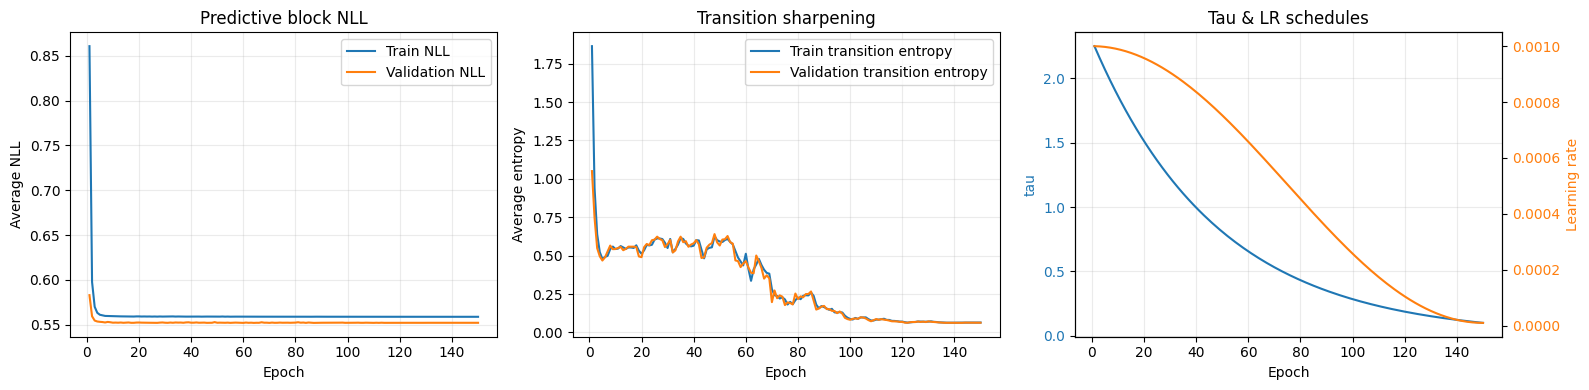

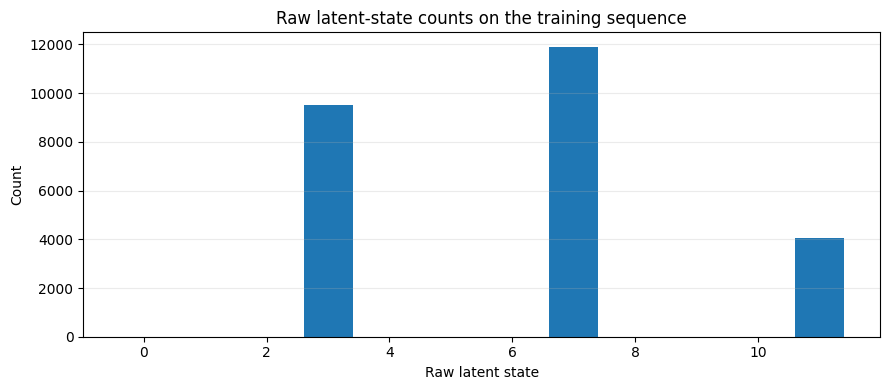

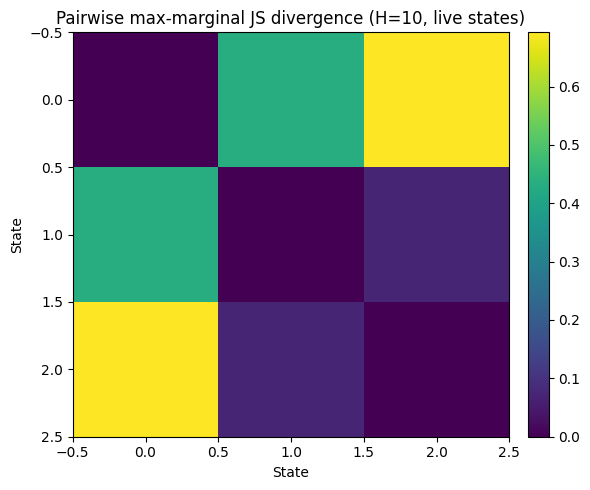

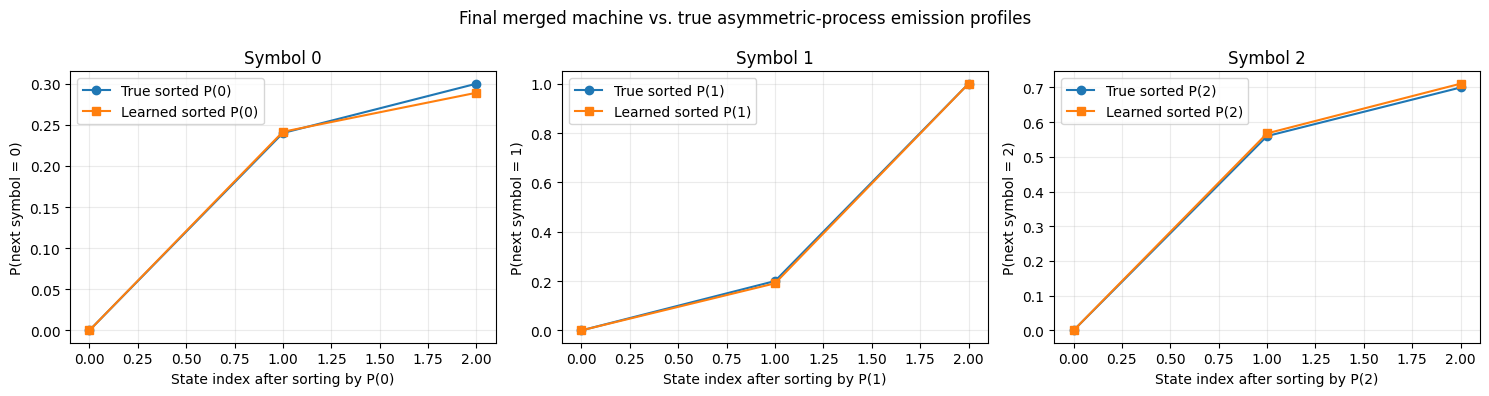

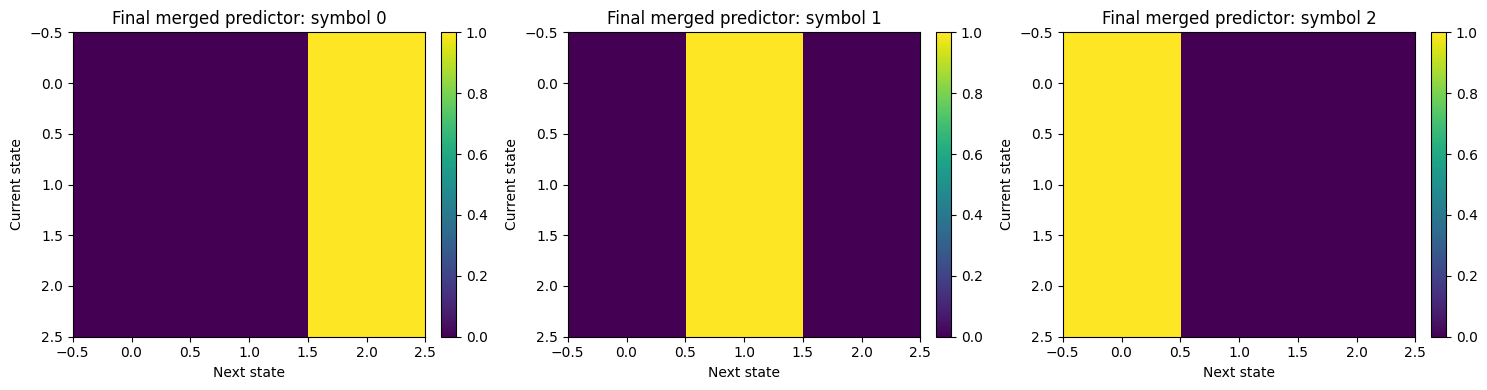

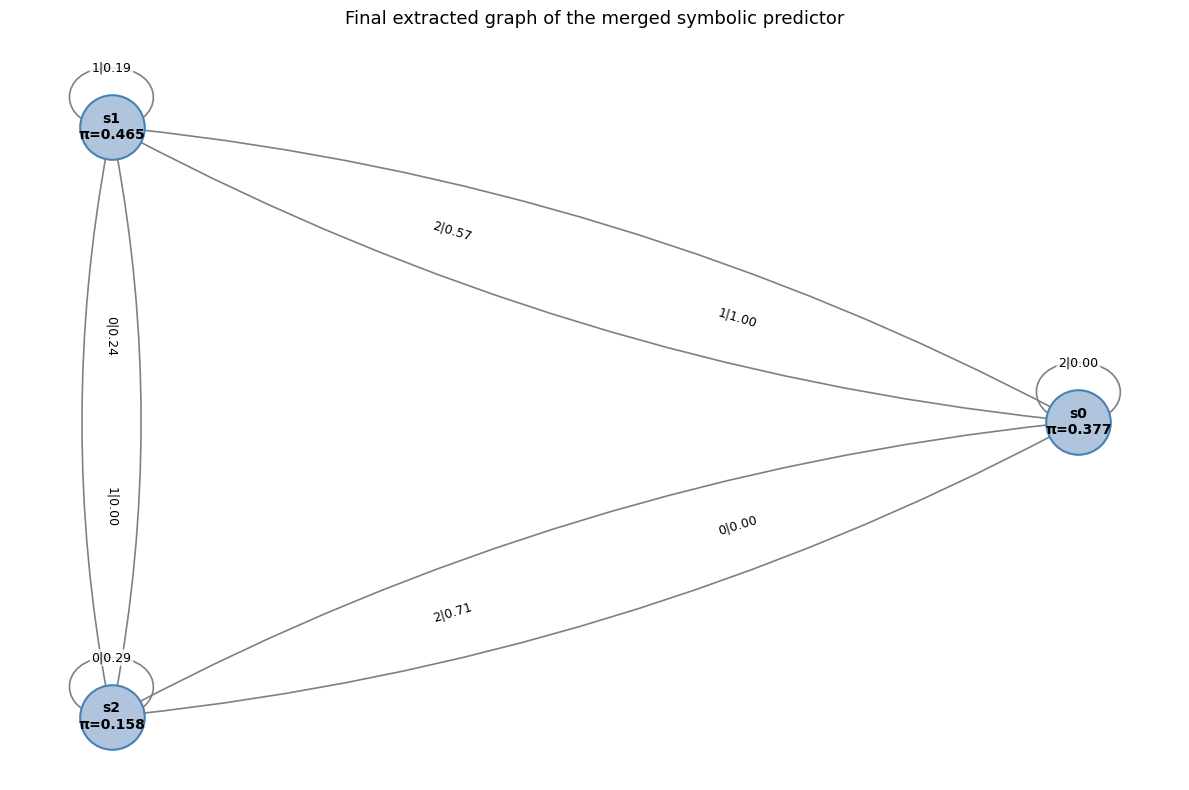

In [10]:

plot_training_curves(results["history"])
plot_state_counts(results["raw_state_counts"], title="Raw latent-state counts on the training sequence")
plot_future_js_heatmap(
    results["raw_marginal_js"],
    title=f"Pairwise max-marginal JS divergence (H={results['cfg'].merge_future_horizon}, live states)",
)
plot_emission_ladder_comparison(
    results["minimal_machine"],
    results["true_machine"],
    title="Final merged machine vs. true asymmetric-process emission profiles",
)
plot_transition_heatmaps(results["minimal_machine"], title_prefix="Final merged predictor")
plot_symbolic_machine_graph(
    results["minimal_machine"],
    stationary_dist=results["minimal_stationary"],
    title="Final extracted graph of the merged symbolic predictor",
)


In [16]:

print("True stationary distribution over asymmetric-process causal states:")
print(np.round(np.sort(results["true_stationary"]), 6))
print()

print("Extracted stationary distribution over merged symbolic states:")
print(np.round(np.sort(results["minimal_stationary"]), 6))
print()

print("Summary table:")
display(results["summary_table"])


True stationary distribution over asymmetric-process causal states:
[0.16     0.373333 0.466667]

Extracted stationary distribution over merged symbolic states:
[0.158052 0.376585 0.465363]

Summary table:


,Metric,Value
0,Neural validation NLL,0.552054
1,Neural test NLL,0.578855
2,Symbolic validation NLL,0.552054
3,Symbolic test NLL,0.578855
4,True validation NLL,0.552178
5,True test NLL,0.577841
6,Last-symbol validation NLL,0.552178
7,Last-symbol test NLL,0.577841
8,Raw machine size,12.000000
9,Live (non-dead) machine size,3.000000


In [17]:

print("Final merged symbolic machine:")
print("next_state:")
print(results["minimal_machine"]["next_state"])
print()
print("emission_probs:")
print(np.round(results["minimal_machine"]["emission_probs"], 6))
print()
if results["merge_log"]:
    print("Merge log:")
    display(pd.DataFrame(results["merge_log"]))
else:
    print("No merges were accepted under the chosen JS threshold.")
    


Final merged symbolic machine:
next_state:
[[2 1 0]
 [2 1 0]
 [2 1 0]]

emission_probs:
[[1.00000e-06 9.99998e-01 1.00000e-06]
 [2.41488e-01 1.90755e-01 5.67757e-01]
 [2.88971e-01 5.30000e-05 7.10976e-01]]

No merges were accepted under the chosen JS threshold.


In [18]:

# --- Quantum compression: Binder, Thompson & Gu (2018) ---

def solve_gram_matrix(emission_probs, next_state, tol=1e-12):
    """Step I: solve the overlap fixed-point equations of Binder et al. (Eq. 7).

    For a finite unifilar machine with transition map lambda(i, x), the overlaps
        c_ij = <sigma_i | sigma_j>
    satisfy the linear system
        c_ij = sum_x sqrt(P(x|i) P(x|j)) c_{lambda(i,x), lambda(j,x)}
    with c_ii = 1.

    We solve directly for the off-diagonal entries, then enforce Hermiticity and
    check positive semidefiniteness. Small negative eigenvalues caused only by
    roundoff are clipped.
    """
    emission_probs = np.asarray(emission_probs, dtype=np.float64)
    next_state = np.asarray(next_state, dtype=np.int64)

    num_states, num_symbols = emission_probs.shape
    if num_states == 1:
        return np.eye(1, dtype=np.complex128)

    pairs = [(i, j) for i in range(num_states) for j in range(i + 1, num_states)]
    pair_to_idx = {pair: idx for idx, pair in enumerate(pairs)}

    A = np.eye(len(pairs), dtype=np.complex128)
    b = np.zeros(len(pairs), dtype=np.complex128)

    for row, (i, j) in enumerate(pairs):
        for x in range(num_symbols):
            fi = int(next_state[i, x])
            fj = int(next_state[j, x])
            coeff = np.sqrt(emission_probs[i, x] * emission_probs[j, x])

            if fi == fj:
                b[row] += coeff
            else:
                a, bp = (fi, fj) if fi < fj else (fj, fi)
                A[row, pair_to_idx[(a, bp)]] -= coeff

    try:
        c_off = np.linalg.solve(A, b)
    except np.linalg.LinAlgError:
        c_off, *_ = np.linalg.lstsq(A, b, rcond=None)

    gram = np.eye(num_states, dtype=np.complex128)
    for idx, (i, j) in enumerate(pairs):
        gram[i, j] = c_off[idx]
        gram[j, i] = np.conj(c_off[idx])

    gram = 0.5 * (gram + gram.conj().T)
    np.fill_diagonal(gram, 1.0)

    fixed = np.zeros_like(gram)
    for i in range(num_states):
        for j in range(num_states):
            total = 0.0 + 0.0j
            for x in range(num_symbols):
                fi = int(next_state[i, x])
                fj = int(next_state[j, x])
                total += np.sqrt(emission_probs[i, x] * emission_probs[j, x]) * gram[fi, fj]
            fixed[i, j] = total

    residual = np.max(np.abs(fixed - gram))
    diag_err = np.max(np.abs(np.diag(gram) - 1.0))

    eigvals, eigvecs = np.linalg.eigh(gram)
    min_eig = float(np.min(np.real(eigvals)))

    if min_eig < -1e-9:
        raise ValueError(
            f"Solved Gram matrix is not positive semidefinite (min eigenvalue = {min_eig:.3e})."
        )

    if min_eig < 0.0:
        eigvals = np.clip(np.real(eigvals), 0.0, None)
        gram = eigvecs @ np.diag(eigvals) @ eigvecs.conj().T
        gram = 0.5 * (gram + gram.conj().T)
        renorm = np.sqrt(np.maximum(np.real(np.diag(gram)), 1e-15))
        gram = gram / renorm[:, None] / renorm[None, :]
        np.fill_diagonal(gram, 1.0)

    gram_solver_info = {
        "fixed_point_residual": float(residual),
        "diagonal_error": float(diag_err),
        "min_eigenvalue": float(np.min(np.real(np.linalg.eigvalsh(gram)))),
    }
    return gram


def gram_to_sigma_states(gram_matrix, tol=1e-12):
    """Step II: build |sigma_i> on the minimal active support of the Gram matrix.

    If G_ij = <sigma_i|sigma_j>, then an eigendecomposition G = V diag(w) V^†
    yields a minimal realization
        sigma = V_pos diag(sqrt(w_pos)),
    where row i of sigma is the coordinate vector of |sigma_i>.
    This automatically handles linear dependence among the memory states.
    """
    gram_matrix = 0.5 * (gram_matrix + gram_matrix.conj().T)
    eigvals, eigvecs = np.linalg.eigh(gram_matrix)
    keep = np.real(eigvals) > tol

    if not np.any(keep):
        raise ValueError("Gram matrix has no positive-eigenvalue support.")

    sigma_states = eigvecs[:, keep] @ np.diag(np.sqrt(np.real(eigvals[keep])))
    reconstruction_error = np.max(np.abs(sigma_states @ sigma_states.conj().T - gram_matrix))

    return sigma_states, {
        "support_rank": int(np.sum(keep)),
        "gram_reconstruction_error": float(reconstruction_error),
        "gram_eigenvalues": np.real(eigvals),
    }


def build_io_matrices(sigma_states, emission_probs, next_state):
    """Build the input and target column sets Psi and Phi appearing in Eq. 5."""
    sigma_states = np.asarray(sigma_states, dtype=np.complex128)
    emission_probs = np.asarray(emission_probs, dtype=np.float64)
    next_state = np.asarray(next_state, dtype=np.int64)

    num_states, num_symbols = emission_probs.shape
    dim_mem = sigma_states.shape[1]
    dim_total = dim_mem * num_symbols

    Psi = np.zeros((dim_total, num_states), dtype=np.complex128)
    Phi = np.zeros((dim_total, num_states), dtype=np.complex128)

    for i in range(num_states):
        for m in range(dim_mem):
            Psi[m * num_symbols + 0, i] = sigma_states[i, m]

        for x in range(num_symbols):
            nxt = int(next_state[i, x])
            for m in range(dim_mem):
                Phi[m * num_symbols + x, i] += np.sqrt(emission_probs[i, x]) * sigma_states[nxt, m]

    return Psi, Phi


def orthonormal_basis_from_columns(matrix, tol=1e-12):
    """Return an orthonormal basis for the column span of matrix."""
    if matrix.size == 0:
        return np.zeros((matrix.shape[0], 0), dtype=np.complex128), 0

    Q, R = np.linalg.qr(matrix, mode="reduced")
    if R.size == 0:
        return np.zeros((matrix.shape[0], 0), dtype=np.complex128), 0

    rank = int(np.sum(np.abs(np.diag(R)) > tol))
    return Q[:, :rank], rank


def orthonormal_complement(Q, tol=1e-12):
    """Return an orthonormal complement of the columns of Q."""
    dim = Q.shape[0]
    if Q.shape[1] == dim:
        return np.zeros((dim, 0), dtype=np.complex128)

    projector = np.eye(dim, dtype=np.complex128) - Q @ Q.conj().T
    projector = 0.5 * (projector + projector.conj().T)
    eigvals, eigvecs = np.linalg.eigh(projector)
    keep = np.real(eigvals) > 0.5
    return eigvecs[:, keep]


def build_q_simulator_unitary(sigma_states, emission_probs, next_state, tol=1e-12):
    """Steps III-IV: construct a unitary U that exactly realizes Eq. 5 on the active support.

    We first obtain orthonormal bases for the spans of the input states Psi and
    target states Phi. Their coordinate matrices share the same Gram matrix, so
    they differ by a support isometry W. We then extend the resulting partial
    isometry to a full unitary by completing both supports to full orthonormal bases.
    """
    Psi, Phi = build_io_matrices(sigma_states, emission_probs, next_state)

    Qin, rank_in = orthonormal_basis_from_columns(Psi, tol)
    Qphi, rank_out = orthonormal_basis_from_columns(Phi, tol)

    if rank_in == 0:
        raise ValueError("The q-simulator input span is trivial.")
    if rank_in != rank_out:
        raise ValueError(
            f"Input/output support rank mismatch: rank(Psi)={rank_in}, rank(Phi)={rank_out}."
        )

    Rin = Qin.conj().T @ Psi
    Rphi = Qphi.conj().T @ Phi

    gram_support = Rin @ Rin.conj().T
    if np.min(np.real(np.linalg.eigvalsh(0.5 * (gram_support + gram_support.conj().T)))) < tol:
        raise ValueError("Support Gram matrix is numerically singular.")

    C = Rphi @ Rin.conj().T
    Uw, _, Vhw = np.linalg.svd(C, full_matrices=False)
    W = Uw @ Vhw
    support_isometry_error = np.max(np.abs(W.conj().T @ W - np.eye(rank_in)))

    support_in = Qin
    support_out = Qphi @ W

    Bin = np.hstack([support_in, orthonormal_complement(support_in, tol)])
    Bout = np.hstack([support_out, orthonormal_complement(support_out, tol)])

    U = Bout @ Bin.conj().T

    exact_residual = np.max(np.abs(U @ Psi - Phi))
    unitary_error = np.max(np.abs(U.conj().T @ U - np.eye(U.shape[0])))

    build_info = {
        "support_rank": int(rank_in),
        "support_isometry_error": float(support_isometry_error),
        "exact_residual": float(exact_residual),
        "unitary_error": float(unitary_error),
    }
    return U, build_info


def stationary_density_matrix(sigma_states, stationary_dist):
    sigma_states = np.asarray(sigma_states, dtype=np.complex128)
    stationary_dist = np.asarray(stationary_dist, dtype=np.float64)

    dim_mem = sigma_states.shape[1]
    rho = np.zeros((dim_mem, dim_mem), dtype=np.complex128)
    for i, p in enumerate(stationary_dist):
        rho += p * np.outer(sigma_states[i], sigma_states[i].conj())
    return rho


def compute_quantum_complexities(sigma_states, stationary_dist, tol=1e-12):
    """Compute C_mu, C_q, C^0_mu, C^0_q using the learned |sigma_i> states."""
    rho = stationary_density_matrix(sigma_states, stationary_dist)
    rho = 0.5 * (rho + rho.conj().T)

    rho_eigvals = np.real(np.linalg.eigvalsh(rho))
    rho_pos = rho_eigvals[rho_eigvals > tol]
    Cq = float(-np.sum(rho_pos * np.log2(np.maximum(rho_pos, 1e-30))))

    stationary_dist = np.asarray(stationary_dist, dtype=np.float64)
    pi_pos = stationary_dist[stationary_dist > tol]
    Cmu = float(-np.sum(pi_pos * np.log2(pi_pos)))

    rank = int(np.sum(rho_eigvals > tol))

    return {
        "Cq": Cq,
        "Cmu": Cmu,
        "C0q": float(np.log2(max(rank, 1))),
        "C0mu": float(np.log2(len(stationary_dist))),
        "rho": rho,
        "rho_eigvals": np.sort(rho_eigvals)[::-1],
        "rank": rank,
    }


def prepare_sigma_blank_state(
    sigma_state,
    dim_mem_active,
    dim_sym_active,
    symbol_pad_dim=None,
    total_dim=None,
):
    """Embed |sigma> |0> into the chosen memory-symbol tensor product basis."""
    sigma_state = np.asarray(sigma_state, dtype=np.complex128)
    symbol_block = dim_sym_active if symbol_pad_dim is None else symbol_pad_dim

    if total_dim is None:
        total_dim = dim_mem_active * symbol_block

    state = np.zeros(total_dim, dtype=np.complex128)
    for m in range(dim_mem_active):
        idx = m * symbol_block + 0
        if idx < total_dim:
            state[idx] = sigma_state[m]

    norm = np.linalg.norm(state)
    if norm > 0:
        state = state / norm
    return state


def partial_trace_symbol(rho_full, dim_mem, dim_sym):
    """Trace out the symbol subsystem for basis ordering |m> tensor |x>."""
    rho_tensor = rho_full.reshape(dim_mem, dim_sym, dim_mem, dim_sym)
    return np.einsum("mxnx->mn", rho_tensor)


def memory_channel(rho_mem, U, dim_mem, dim_sym):
    blank = np.zeros((dim_sym, dim_sym), dtype=np.complex128)
    blank[0, 0] = 1.0
    rho_full = np.kron(rho_mem, blank)
    rho_out = U @ rho_full @ U.conj().T
    return partial_trace_symbol(rho_out, dim_mem, dim_sym)


def machine_word_distribution(emission_probs, next_state, start_state, length):
    """Exact classical word distribution P(x_{0:L} | start_state)."""
    emission_probs = np.asarray(emission_probs, dtype=np.float64)
    next_state = np.asarray(next_state, dtype=np.int64)
    num_symbols = emission_probs.shape[1]

    distribution = {}

    def recurse(state, depth, prob, word):
        if depth == length:
            distribution[word] = distribution.get(word, 0.0) + prob
            return

        for x in range(num_symbols):
            p = float(emission_probs[state, x])
            if p > 0.0:
                recurse(int(next_state[state, x]), depth + 1, prob * p, word + (x,))

    recurse(int(start_state), 0, 1.0, tuple())
    return distribution


def qsim_word_distribution(U, sigma_states, start_state, length, num_symbols, tol=1e-14):
    """Exact q-simulator word distribution from repeated application of the same unitary."""
    sigma_states = np.asarray(sigma_states, dtype=np.complex128)
    dim_mem = sigma_states.shape[1]
    distribution = {}

    def recurse(memory_state, depth, prob, word):
        if depth == length:
            distribution[word] = distribution.get(word, 0.0) + prob
            return

        state_in = prepare_sigma_blank_state(memory_state, dim_mem, num_symbols)
        state_out = U @ state_in

        for x in range(num_symbols):
            post = np.array(
                [state_out[m * num_symbols + x] for m in range(dim_mem)],
                dtype=np.complex128,
            )
            px = float(np.sum(np.abs(post) ** 2))
            if px > tol:
                recurse(post / np.sqrt(px), depth + 1, prob * px, word + (x,))

    recurse(sigma_states[int(start_state)], 0, 1.0, tuple())
    return distribution


def stationary_word_distribution_from_machine(emission_probs, next_state, stationary_dist, length):
    distribution = {}
    for i, p in enumerate(np.asarray(stationary_dist, dtype=np.float64)):
        if p <= 0:
            continue
        dist_i = machine_word_distribution(emission_probs, next_state, i, length)
        for word, prob in dist_i.items():
            distribution[word] = distribution.get(word, 0.0) + p * prob
    return distribution


def stationary_word_distribution_from_qsim(U, sigma_states, stationary_dist, num_symbols, length):
    distribution = {}
    for i, p in enumerate(np.asarray(stationary_dist, dtype=np.float64)):
        if p <= 0:
            continue
        dist_i = qsim_word_distribution(U, sigma_states, i, length, num_symbols)
        for word, prob in dist_i.items():
            distribution[word] = distribution.get(word, 0.0) + p * prob
    return distribution


def word_distribution_tv_distance(p_true, p_model):
    keys = set(p_true) | set(p_model)
    return 0.5 * sum(abs(p_true.get(k, 0.0) - p_model.get(k, 0.0)) for k in keys)


def word_distribution_cross_entropy(p_true, p_model, eps=1e-12):
    total = 0.0
    for word, prob in p_true.items():
        if prob > 0:
            total += -prob * np.log(max(p_model.get(word, 0.0), eps))
    return float(total)


def conditional_cross_entropy(stationary_dist, true_conditional, model_conditional, eps=1e-12):
    stationary_dist = np.asarray(stationary_dist, dtype=np.float64)
    true_conditional = np.asarray(true_conditional, dtype=np.float64)
    model_conditional = np.asarray(model_conditional, dtype=np.float64)

    total = 0.0
    for i, p_state in enumerate(stationary_dist):
        for x in range(true_conditional.shape[1]):
            total += -p_state * true_conditional[i, x] * np.log(max(model_conditional[i, x], eps))
    return float(total)


def verify_q_simulator(
    U,
    sigma_states,
    emission_probs,
    next_state,
    stationary_dist=None,
    word_lengths=(2, 3, 4),
    tol=1e-10,
):
    """Verify exact Binder-style conditions for the q-simulator construction."""
    emission_probs = np.asarray(emission_probs, dtype=np.float64)
    next_state = np.asarray(next_state, dtype=np.int64)
    sigma_states = np.asarray(sigma_states, dtype=np.complex128)

    num_states, num_symbols = emission_probs.shape
    dim_mem = sigma_states.shape[1]

    max_eq5_error = 0.0
    max_emission_error = 0.0
    max_state_overlap_error = 0.0

    for i in range(num_states):
        lhs = U @ prepare_sigma_blank_state(sigma_states[i], dim_mem, num_symbols)

        rhs = np.zeros(dim_mem * num_symbols, dtype=np.complex128)
        for x in range(num_symbols):
            nxt = int(next_state[i, x])
            for m in range(dim_mem):
                rhs[m * num_symbols + x] += np.sqrt(emission_probs[i, x]) * sigma_states[nxt, m]

        max_eq5_error = max(max_eq5_error, float(np.linalg.norm(lhs - rhs)))

        for x in range(num_symbols):
            post = np.array(
                [lhs[m * num_symbols + x] for m in range(dim_mem)],
                dtype=np.complex128,
            )
            prob = float(np.sum(np.abs(post) ** 2))
            max_emission_error = max(max_emission_error, abs(prob - emission_probs[i, x]))

            if prob > tol:
                post = post / np.sqrt(prob)
                target = sigma_states[int(next_state[i, x])]
                target = target / np.linalg.norm(target)
                overlap = abs(np.vdot(post, target))
                max_state_overlap_error = max(
                    max_state_overlap_error,
                    float(1.0 - overlap),
                )

    max_word_error_by_length = {}
    for length in word_lengths:
        max_word_error = 0.0
        for i in range(num_states):
            dist_machine = machine_word_distribution(emission_probs, next_state, i, length)
            dist_qsim = qsim_word_distribution(U, sigma_states, i, length, num_symbols)
            for word in set(dist_machine) | set(dist_qsim):
                max_word_error = max(
                    max_word_error,
                    abs(dist_machine.get(word, 0.0) - dist_qsim.get(word, 0.0)),
                )
        max_word_error_by_length[int(length)] = float(max_word_error)

    fixed_point_error = None
    if stationary_dist is not None:
        rho = stationary_density_matrix(sigma_states, stationary_dist)
        rho_out = memory_channel(rho, U, dim_mem, num_symbols)
        fixed_point_error = float(np.max(np.abs(rho_out - rho)))

    return {
        "eq5_error": float(max_eq5_error),
        "unitarity_error": float(np.max(np.abs(U.conj().T @ U - np.eye(U.shape[0])))),
        "max_emission_error": float(max_emission_error),
        "max_state_overlap_error": float(max_state_overlap_error),
        "max_word_error_by_length": max_word_error_by_length,
        "fixed_point_error": fixed_point_error,
    }


In [19]:

print("=" * 70)
print("QUANTUM COMPRESSION OF EXTRACTED EPSILON-MACHINE")
print("=" * 70)

machine = results["minimal_machine"]
em_probs = np.asarray(machine["emission_probs"], dtype=np.float64)
ns = np.asarray(machine["next_state"], dtype=np.int64)
num_states = em_probs.shape[0]
dim_sym_active = em_probs.shape[1]
pi_learned = np.asarray(results["minimal_stationary"], dtype=np.float64)

print(f"\nExtracted machine: {num_states} causal states")
print(f"Alphabet size: {dim_sym_active}")
print(f"Classical memory dimension: {num_states} states")

# Step I
print("\n--- Step I: Solve Gram matrix (Eq. 7) ---")
gram = solve_gram_matrix(em_probs, ns)
gram_eigs = np.real(np.linalg.eigvalsh(gram))
print(f"Gram matrix eigenvalues: {np.round(gram_eigs, 8)}")
print(f"Gram matrix Hermitian: {np.allclose(gram, gram.conj().T, atol=1e-10)}")
print(f"Gram matrix PSD: {np.all(gram_eigs > -1e-10)}")

# Step II
print("\n--- Step II: Minimal-support realization of |sigma_i> ---")
sigma, sigma_info = gram_to_sigma_states(gram)
dim_mem_active = sigma.shape[1]
print(f"Active quantum memory dimension: {dim_mem_active}")
print(f"Gram reconstruction error: {sigma_info['gram_reconstruction_error']:.2e}")

# Steps III-IV
print("\n--- Steps III-IV: Exact unitary q-simulator construction ---")
U_q, unitary_build_info = build_q_simulator_unitary(sigma, em_probs, ns)
print(f"Unitary dimension on active support: {U_q.shape[0]} x {U_q.shape[1]}")
print(f"Exact map residual ||U Psi - Phi||_max: {unitary_build_info['exact_residual']:.2e}")
print(f"Support-isometry error: {unitary_build_info['support_isometry_error']:.2e}")
print(f"Unitary error ||U^dagger U - I||_max: {unitary_build_info['unitary_error']:.2e}")

# Verification
print("\n--- Verification against Binder et al. conditions ---")
verification = verify_q_simulator(
    U_q,
    sigma,
    em_probs,
    ns,
    stationary_dist=pi_learned,
    word_lengths=(2, 3, 4),
)
print(f"Eq. (5) residual:              {verification['eq5_error']:.2e}")
print(f"One-step emission error:       {verification['max_emission_error']:.2e}")
print(f"Post-measurement state error:  {verification['max_state_overlap_error']:.2e}")
print(f"Fixed-point error on rho:      {verification['fixed_point_error']:.2e}")
for L, err in verification['max_word_error_by_length'].items():
    print(f"Max word-probability error (L={L}): {err:.2e}")

# Complexity comparison
print("\n--- Complexity comparison (Eqs. 3, 4, 8, 9) ---")
complexities = compute_quantum_complexities(sigma, pi_learned)
print(f"Classical statistical complexity C_mu:      {complexities['Cmu']:.6f} bits")
print(f"Quantum statistical complexity C_q:         {complexities['Cq']:.6f} bits")
print(f"Classical topological complexity C_0_mu:    {complexities['C0mu']:.6f} bits (log2({num_states}))")
print(f"Quantum topological complexity C_0_q:       {complexities['C0q']:.6f} bits (log2({complexities['rank']}))")
print(f"\nEntropic advantage C_mu / C_q:             {complexities['Cmu'] / max(complexities['Cq'], 1e-15):.4f}x")
print(f"Dimensional advantage C_0_mu / C_0_q:      {complexities['C0mu'] / max(complexities['C0q'], 1e-15):.4f}x")
print(f"Memory saved (entropic):                   {(1 - complexities['Cq'] / max(complexities['Cmu'], 1e-15)) * 100:.1f}%")

# Matched exact metrics for later noisy comparisons
symbolic_one_step_ce = conditional_cross_entropy(pi_learned, em_probs, em_probs)
qsim_exact_one_step_probs = em_probs.copy()
qsim_exact_one_step_ce = conditional_cross_entropy(pi_learned, em_probs, qsim_exact_one_step_probs)

word_length_eval = 4
stationary_machine_words = stationary_word_distribution_from_machine(em_probs, ns, pi_learned, word_length_eval)
stationary_qsim_words = stationary_word_distribution_from_qsim(U_q, sigma, pi_learned, dim_sym_active, word_length_eval)
stationary_word_tv_exact = word_distribution_tv_distance(stationary_machine_words, stationary_qsim_words)
stationary_word_ce_symbolic = word_distribution_cross_entropy(stationary_machine_words, stationary_machine_words)
stationary_word_ce_qsim = word_distribution_cross_entropy(stationary_machine_words, stationary_qsim_words)

print(f"\nMatched one-step cross-entropy (symbolic machine): {symbolic_one_step_ce:.6f} nats/symbol")
print(f"Matched one-step cross-entropy (ideal q-sim):      {qsim_exact_one_step_ce:.6f} nats/symbol")
print(f"Stationary {word_length_eval}-word TV distance (ideal q-sim): {stationary_word_tv_exact:.2e}")
print(f"Stationary {word_length_eval}-word cross-entropy (ideal q-sim): {stationary_word_ce_qsim:.6f} nats/word")

# Also compute the same quantities for the true asymmetric-process machine
print("\n--- True asymmetric-process machine comparison ---")
true_m = results["true_machine"]
true_pi = np.asarray(results["true_stationary"], dtype=np.float64)
true_em = np.asarray(true_m["emission_probs"], dtype=np.float64)
true_ns = np.asarray(true_m["next_state"], dtype=np.int64)

gram_true = solve_gram_matrix(true_em, true_ns)
sigma_true, sigma_true_info = gram_to_sigma_states(gram_true)
U_true, build_true = build_q_simulator_unitary(sigma_true, true_em, true_ns)
cx_true = compute_quantum_complexities(sigma_true, true_pi)
ver_true = verify_q_simulator(U_true, sigma_true, true_em, true_ns, stationary_dist=true_pi, word_lengths=(2, 3, 4))

print(f"True process active quantum memory dimension: {sigma_true.shape[1]}")
print(f"True process exact map residual: {build_true['exact_residual']:.2e}")
print(f"True process fixed-point error:  {ver_true['fixed_point_error']:.2e}")
print(
    f"True process: C_mu = {cx_true['Cmu']:.6f}, C_q = {cx_true['Cq']:.6f}, "
    f"ratio = {cx_true['Cmu'] / max(cx_true['Cq'], 1e-15):.4f}x"
)


QUANTUM COMPRESSION OF EXTRACTED EPSILON-MACHINE

Extracted machine: 3 causal states
Alphabet size: 3
Classical memory dimension: 3 states

--- Step I: Solve Gram matrix (Eq. 7) ---
Gram matrix eigenvalues: [4.25900000e-05 9.93130760e-01 2.00682665e+00]
Gram matrix Hermitian: True
Gram matrix PSD: True

--- Step II: Minimal-support realization of |sigma_i> ---
Active quantum memory dimension: 3
Gram reconstruction error: 1.34e-16

--- Steps III-IV: Exact unitary q-simulator construction ---
Unitary dimension on active support: 9 x 9
Exact map residual ||U Psi - Phi||_max: 9.62e-07
Support-isometry error: 1.11e-16
Unitary error ||U^dagger U - I||_max: 8.88e-16

--- Verification against Binder et al. conditions ---
Eq. (5) residual:              1.28e-06
One-step emission error:       1.08e-06
Post-measurement state error:  1.11e-16
Fixed-point error on rho:      2.55e-07
Max word-probability error (L=2): 1.09e-06
Max word-probability error (L=3): 1.19e-06
Max word-probability error (L=4

QISKIT CIRCUIT SYNTHESIS
Active-support U dimension: 9x9 (memory dim=3, symbol dim=3)
Padded to qubits: 16x16 (4 qubits = 2 symbol + 2 memory)
Padded unitarity error: 8.88e-16

Raw circuit depth before decomposition is not operationally meaningful for a unitary block.
Q-Simulator step qubits: 4
Transpiled one-step depth: 188
Transpiled one-step size:  255
Transpiled one-step gate counts: {'u': 98, 'cx': 95, 'rz': 52, 'u2': 10}


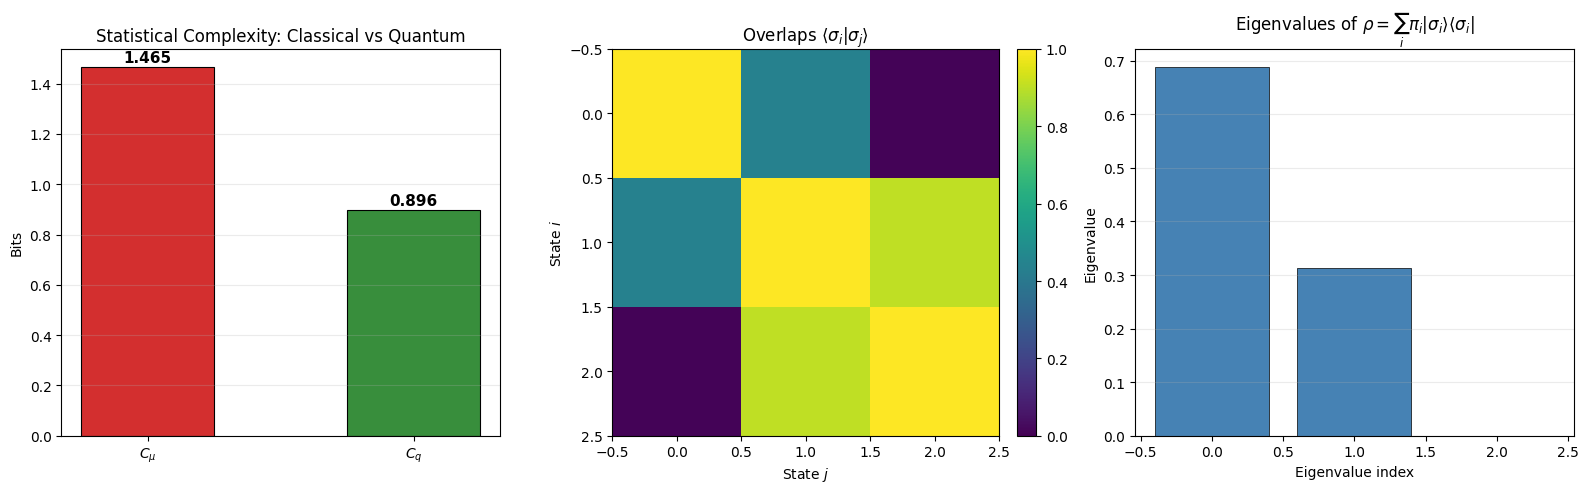

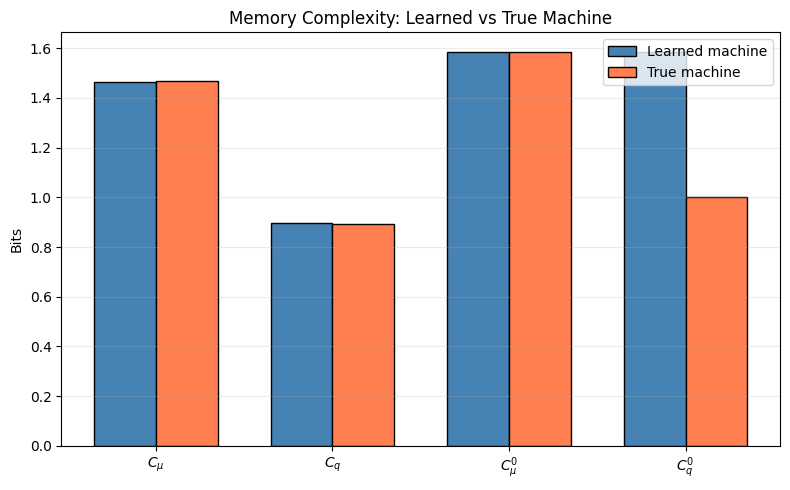


SUMMARY
Extracted epsilon-machine: 3 causal states
Active quantum memory dimension: 3
Quantum memory after qubit padding: 2 qubits (Hilbert-space dimension 4)
Classical memory: 1.4648 bits (C_mu) / 1.5850 bits (C_0_mu)
Quantum memory:   0.8959 bits (C_q)  / 1.5850 bits (C_0_q)
Entropic compression: 38.8% memory reduction
Exact theory checks: Eq.(5) residual=1.28e-06, rho fixed-point error=2.55e-07
Representative one-step interaction cost after transpilation: depth=188, size=255


In [20]:

from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit, QuantumRegister

# --- Qiskit circuit synthesis ---
print("=" * 70)
print("QISKIT CIRCUIT SYNTHESIS")
print("=" * 70)

def pad_unitary_for_qubits(U_active, dim_mem_active, dim_sym_active):
    """Pad the active-support unitary to full qubit dimensions.

    We keep the symbol register on the least-significant qubits so that basis
    index = memory_index * symbol_pad_dim + symbol_index.
    """
    n_mem_qubits = int(np.ceil(np.log2(max(dim_mem_active, 1))))
    n_sym_qubits = int(np.ceil(np.log2(max(dim_sym_active, 1))))

    dim_mem_padded = 2 ** n_mem_qubits
    dim_sym_padded = 2 ** n_sym_qubits
    dim_total_padded = dim_mem_padded * dim_sym_padded

    U_padded = np.eye(dim_total_padded, dtype=np.complex128)

    for row_m in range(dim_mem_active):
        for row_x in range(dim_sym_active):
            for col_m in range(dim_mem_active):
                for col_x in range(dim_sym_active):
                    old_row = row_m * dim_sym_active + row_x
                    old_col = col_m * dim_sym_active + col_x
                    new_row = row_m * dim_sym_padded + row_x
                    new_col = col_m * dim_sym_padded + col_x
                    U_padded[new_row, new_col] = U_active[old_row, old_col]

    layout = {
        "n_mem_qubits": n_mem_qubits,
        "n_sym_qubits": n_sym_qubits,
        "dim_mem_padded": dim_mem_padded,
        "dim_sym_padded": dim_sym_padded,
        "dim_total_padded": dim_total_padded,
    }
    return U_padded, layout


def fully_decompose(qc, max_passes=20):
    """Decompose repeatedly until only standard basis-gate style instructions remain."""
    basis = {
        "u", "u1", "u2", "u3", "p", "rz", "ry", "rx", "sx", "x", "y", "z", "h",
        "s", "sdg", "t", "tdg", "id", "cx", "cz", "cy", "swap", "ecr",
        "measure", "reset", "barrier"
    }
    qc_dec = qc.copy()
    for _ in range(max_passes):
        gate_names = set(qc_dec.count_ops().keys())
        if gate_names.issubset(basis):
            break
        qc_dec = qc_dec.decompose()
    return qc_dec


U_padded, qiskit_layout = pad_unitary_for_qubits(U_q, dim_mem_active, dim_sym_active)
n_mem_qubits = qiskit_layout["n_mem_qubits"]
n_sym_qubits = qiskit_layout["n_sym_qubits"]
dim_mem_padded = qiskit_layout["dim_mem_padded"]
dim_sym_padded = qiskit_layout["dim_sym_padded"]
dim_total_padded = qiskit_layout["dim_total_padded"]
n_total_qubits = n_mem_qubits + n_sym_qubits

print(
    f"Active-support U dimension: {U_q.shape[0]}x{U_q.shape[1]} "
    f"(memory dim={dim_mem_active}, symbol dim={dim_sym_active})"
)
print(
    f"Padded to qubits: {dim_total_padded}x{dim_total_padded} "
    f"({n_total_qubits} qubits = {n_sym_qubits} symbol + {n_mem_qubits} memory)"
)

pad_err = np.max(np.abs(U_padded.conj().T @ U_padded - np.eye(dim_total_padded)))
print(f"Padded unitarity error: {pad_err:.2e}")
assert pad_err < 1e-8, f"U_padded is not unitary (error={pad_err:.2e})."

# Build the one-step interaction circuit with symbol qubits first in the register order.
sym_reg = QuantumRegister(n_sym_qubits, "sym")
mem_reg = QuantumRegister(n_mem_qubits, "mem")
qc_step = QuantumCircuit(sym_reg, mem_reg, name="Q-Simulator-step")
qc_step.unitary(Operator(U_padded), qc_step.qubits, label="U_q")

print("\nRaw circuit depth before decomposition is not operationally meaningful for a unitary block.")
print(f"Q-Simulator step qubits: {qc_step.num_qubits}")

step_gate_counts = {}
step_transpiled_depth = None
step_transpiled_size = None

try:
    from qiskit_aer import AerSimulator
    from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

    backend_ref = AerSimulator()
    pm_ref = generate_preset_pass_manager(optimization_level=2, backend=backend_ref)
    qc_step_t = pm_ref.run(fully_decompose(qc_step))

    step_gate_counts = dict(qc_step_t.count_ops())
    step_transpiled_depth = qc_step_t.depth()
    step_transpiled_size = qc_step_t.size()

    print(f"Transpiled one-step depth: {step_transpiled_depth}")
    print(f"Transpiled one-step size:  {step_transpiled_size}")
    print(f"Transpiled one-step gate counts: {step_gate_counts}")
except Exception as exc:
    print(f"Transpilation summary unavailable in this runtime: {exc}")

# --- Visualization ---

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Quantum vs Classical complexity bar chart
labels_bar = ["$C_{\\mu}$", "$C_q$"]
values = [complexities["Cmu"], complexities["Cq"]]
axes[0].bar(labels_bar, values, color=["#d32f2f", "#388e3c"], width=0.5, edgecolor="black", linewidth=0.8)
axes[0].set_ylabel("Bits")
axes[0].set_title("Statistical Complexity: Classical vs Quantum")
for idx, value in enumerate(values):
    axes[0].text(idx, value + 0.02, f"{value:.3f}", ha="center", fontsize=11, fontweight="bold")
axes[0].grid(axis="y", alpha=0.25)

# 2. Quantum memory-state overlap heatmap
im = axes[1].imshow(np.real_if_close(gram), cmap="viridis", vmin=0, vmax=1)
axes[1].set_title("Overlaps $\\langle \\sigma_i | \\sigma_j \\rangle$")
axes[1].set_xlabel("State $j$")
axes[1].set_ylabel("State $i$")
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# 3. Eigenvalue spectrum of the stationary quantum memory state rho
rho_eigs = complexities["rho_eigvals"]
axes[2].bar(range(len(rho_eigs)), rho_eigs, color="steelblue", edgecolor="black", linewidth=0.5)
axes[2].set_title("Eigenvalues of $\\rho = \\sum_i \\pi_i |\\sigma_i\\rangle\\langle\\sigma_i|$")
axes[2].set_xlabel("Eigenvalue index")
axes[2].set_ylabel("Eigenvalue")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

# Learned vs true comparison
if "cx_true" in globals():
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    x_pos = np.arange(4)
    width = 0.35
    learned_vals = [complexities["Cmu"], complexities["Cq"], complexities["C0mu"], complexities["C0q"]]
    true_vals = [cx_true["Cmu"], cx_true["Cq"], cx_true["C0mu"], cx_true["C0q"]]
    ax2.bar(x_pos - width / 2, learned_vals, width, label="Learned machine", color="steelblue", edgecolor="black")
    ax2.bar(x_pos + width / 2, true_vals, width, label="True machine", color="coral", edgecolor="black")
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(["$C_{\\mu}$", "$C_q$", "$C^0_{\\mu}$", "$C^0_q$"])
    ax2.set_ylabel("Bits")
    ax2.set_title("Memory Complexity: Learned vs True Machine")
    ax2.legend()
    ax2.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
print(f"Extracted epsilon-machine: {num_states} causal states")
print(f"Active quantum memory dimension: {dim_mem_active}")
print(
    f"Quantum memory after qubit padding: {n_mem_qubits} qubits "
    f"(Hilbert-space dimension {dim_mem_padded})"
)
print(f"Classical memory: {complexities['Cmu']:.4f} bits (C_mu) / {complexities['C0mu']:.4f} bits (C_0_mu)")
print(f"Quantum memory:   {complexities['Cq']:.4f} bits (C_q)  / {complexities['C0q']:.4f} bits (C_0_q)")
print(f"Entropic compression: {(1 - complexities['Cq'] / max(complexities['Cmu'], 1e-15)) * 100:.1f}% memory reduction")
print(
    f"Exact theory checks: Eq.(5) residual={verification['eq5_error']:.2e}, "
    f"rho fixed-point error={verification['fixed_point_error']:.2e}"
)
if step_transpiled_depth is not None:
    print(
        f"Representative one-step interaction cost after transpilation: "
        f"depth={step_transpiled_depth}, size={step_transpiled_size}"
    )


NOISY Q-SIMULATOR: SEQUENTIAL MEMORY-CARRYING TEST

--- Step 1: Exact sequential benchmarks on the extracted machine ---
Matched one-step cross-entropy (symbolic machine): 0.551442 nats/symbol
Matched one-step cross-entropy (ideal q-sim):      0.551442 nats/symbol
Stationary 4-word TV distance (ideal q-sim): 1.57e-06
Stationary 4-word cross-entropy (ideal q-sim): 2.669655 nats/word

--- Step 2: Build sequential circuits with persistent memory ---
Representative sequential circuit gate counts (state 0): {'u': 618, 'cx': 391, 'u2': 40, 'reset': 10, 'measure': 8, 'u1': 3, 'u3': 1}
Representative sequential circuit depth (state 0): 781
State-preparation is included only at t=0; the repeated interaction cost per step is reported above in the synthesis cell.

--- Step 3: Sequential noisy simulations ---
Running Low noise (1q=0.0005, 2q=0.005)...
  one-step CE = 0.773496 +/- 0.003650, 4-word TV = 0.633803 +/- 0.004004, invalid word mass = 0.291998
Running Medium noise (1q=0.002, 2q=0.02)...
 

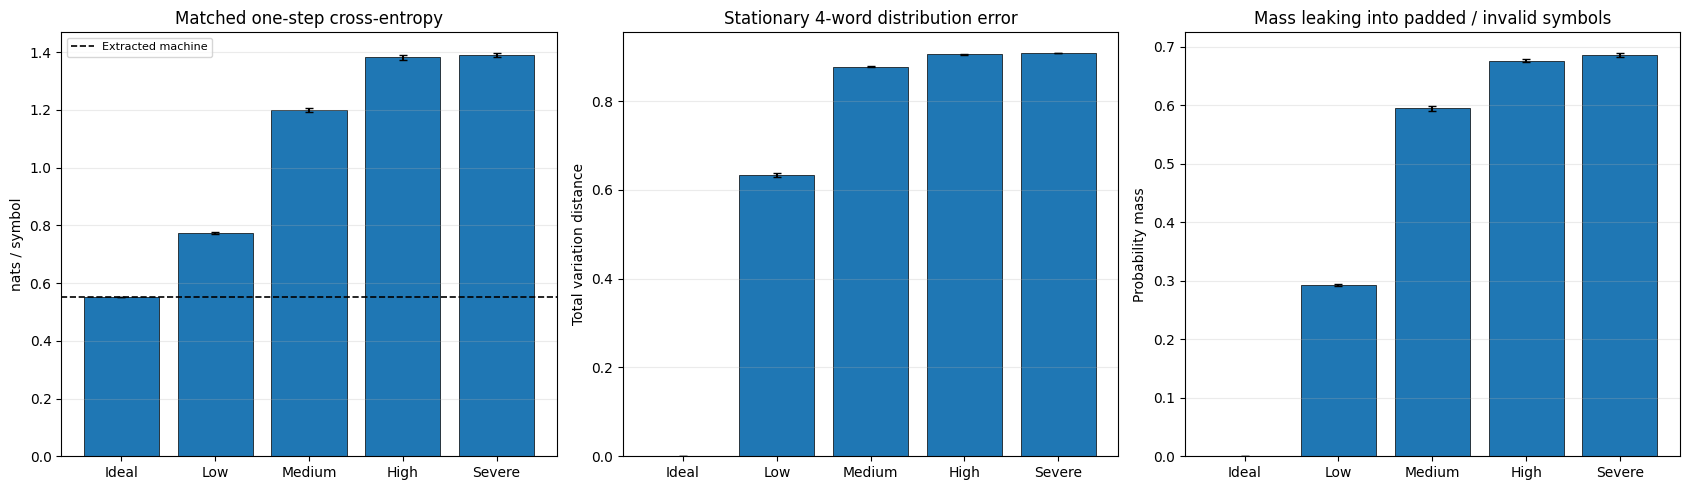


Key findings:
  1. The ideal q-simulator matches the extracted machine exactly at both the one-step and 4-word levels.
  2. Under low noise, the matched one-step cross-entropy increases by 0.222054 nats/symbol.
  3. Under severe noise, the stationary 4-word TV distance is 0.908425 and the invalid-word mass is 0.686161.
  4. The repeated interaction cost per simulation step is determined by the transpiled one-step gate counts reported in the synthesis cell: {'u': 98, 'cx': 95, 'rz': 52, 'u2': 10}.
  5. This noisy experiment now keeps the memory register alive across time, measures only the symbol ancilla at each step, resets that ancilla, and then reapplies the same unitary, matching the sequential operational picture of the paper.


In [21]:

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.quantum_info import Operator
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister

print("=" * 70)
print("NOISY Q-SIMULATOR: SEQUENTIAL MEMORY-CARRYING TEST")
print("=" * 70)

def build_sequential_qsim_circuit(init_statevector, U_padded_mat, n_sym_qubits, n_mem_qubits, seq_length):
    """Build a sequential q-simulator circuit with persistent memory and reset ancilla."""
    sym_reg = QuantumRegister(n_sym_qubits, "sym")
    mem_reg = QuantumRegister(n_mem_qubits, "mem")
    c_reg = ClassicalRegister(seq_length * n_sym_qubits, "c")
    qc = QuantumCircuit(sym_reg, mem_reg, c_reg)

    qc.initialize(np.asarray(init_statevector, dtype=np.complex128), qc.qubits)

    for t in range(seq_length):
        qc.unitary(Operator(U_padded_mat), qc.qubits, label="U_q")
        c_slice = list(c_reg[t * n_sym_qubits : (t + 1) * n_sym_qubits])
        qc.measure(sym_reg, c_slice)
        if t < seq_length - 1:
            qc.reset(sym_reg)

    return qc


def bitstring_to_word(bitstring, seq_length, n_sym_qubits):
    """Parse a Qiskit count key into a tuple of emitted symbol integers."""
    bits = bitstring.replace(" ", "")[::-1]  # c0 first
    symbols = []
    for t in range(seq_length):
        chunk_lsb_first = bits[t * n_sym_qubits : (t + 1) * n_sym_qubits]
        if len(chunk_lsb_first) < n_sym_qubits:
            chunk_lsb_first = chunk_lsb_first.ljust(n_sym_qubits, "0")
        symbols.append(int(chunk_lsb_first[::-1], 2))
    return tuple(symbols)


def counts_to_word_distribution(counts, seq_length, n_sym_qubits):
    total = max(sum(counts.values()), 1)
    distribution = {}
    for bitstring, count in counts.items():
        word = bitstring_to_word(bitstring, seq_length, n_sym_qubits)
        distribution[word] = distribution.get(word, 0.0) + count / total
    return distribution


def first_symbol_marginals_from_word_distribution(word_distribution, alphabet_size):
    probs = np.zeros(alphabet_size, dtype=np.float64)
    invalid_mass = 0.0
    for word, prob in word_distribution.items():
        first_symbol = int(word[0])
        if 0 <= first_symbol < alphabet_size:
            probs[first_symbol] += prob
        else:
            invalid_mass += prob
    return probs, invalid_mass


def invalid_word_mass(word_distribution, alphabet_size):
    total = 0.0
    for word, prob in word_distribution.items():
        if any((symbol < 0) or (symbol >= alphabet_size) for symbol in word):
            total += prob
    return total


print("\n--- Step 1: Exact sequential benchmarks on the extracted machine ---")
print(f"Matched one-step cross-entropy (symbolic machine): {symbolic_one_step_ce:.6f} nats/symbol")
print(f"Matched one-step cross-entropy (ideal q-sim):      {qsim_exact_one_step_ce:.6f} nats/symbol")
print(f"Stationary {word_length_eval}-word TV distance (ideal q-sim): {stationary_word_tv_exact:.2e}")
print(f"Stationary {word_length_eval}-word cross-entropy (ideal q-sim): {stationary_word_ce_qsim:.6f} nats/word")

print("\n--- Step 2: Build sequential circuits with persistent memory ---")
reference_backend = AerSimulator()
pm_ref = generate_preset_pass_manager(optimization_level=2, backend=reference_backend)

sequential_circuits = []
for i in range(num_states):
    init_sv = prepare_sigma_blank_state(
        sigma[i],
        dim_mem_active=dim_mem_active,
        dim_sym_active=dim_sym_active,
        symbol_pad_dim=dim_sym_padded,
        total_dim=dim_total_padded,
    )
    qc_seq = build_sequential_qsim_circuit(
        init_statevector=init_sv,
        U_padded_mat=U_padded,
        n_sym_qubits=n_sym_qubits,
        n_mem_qubits=n_mem_qubits,
        seq_length=word_length_eval,
    )
    qc_seq_t = pm_ref.run(fully_decompose(qc_seq))
    sequential_circuits.append(qc_seq_t)

seq_gate_counts = dict(sequential_circuits[0].count_ops()) if sequential_circuits else {}
print(f"Representative sequential circuit gate counts (state 0): {seq_gate_counts}")
print(f"Representative sequential circuit depth (state 0): {sequential_circuits[0].depth() if sequential_circuits else 'N/A'}")
print("State-preparation is included only at t=0; the repeated interaction cost per step is reported above in the synthesis cell.")

def run_noisy_sequential_trials(
    transpiled_circuits,
    stationary_dist,
    alphabet_size,
    seq_length,
    n_sym_qubits,
    noise_model,
    shots=4096,
    n_trials=3,
):
    backend = AerSimulator(noise_model=noise_model)

    trial_metrics = []
    trial_first_symbol = []

    for _ in range(n_trials):
        result = backend.run(transpiled_circuits, shots=shots).result()

        per_state_word_distributions = []
        per_state_first_symbol = np.zeros((len(transpiled_circuits), alphabet_size), dtype=np.float64)
        per_state_invalid_first = np.zeros(len(transpiled_circuits), dtype=np.float64)

        for i in range(len(transpiled_circuits)):
            counts = result.get_counts(i)
            word_dist = counts_to_word_distribution(counts, seq_length, n_sym_qubits)
            per_state_word_distributions.append(word_dist)

            first_probs, invalid_first = first_symbol_marginals_from_word_distribution(word_dist, alphabet_size)
            per_state_first_symbol[i] = first_probs
            per_state_invalid_first[i] = invalid_first

        stationary_word_dist = {}
        for i, p_state in enumerate(stationary_dist):
            for word, prob in per_state_word_distributions[i].items():
                stationary_word_dist[word] = stationary_word_dist.get(word, 0.0) + p_state * prob

        one_step_ce = conditional_cross_entropy(
            stationary_dist=stationary_dist,
            true_conditional=em_probs,
            model_conditional=np.clip(per_state_first_symbol, 1e-12, 1.0),
        )
        word_tv = word_distribution_tv_distance(stationary_machine_words, stationary_word_dist)
        word_ce = word_distribution_cross_entropy(stationary_machine_words, stationary_word_dist)
        invalid_mass = invalid_word_mass(stationary_word_dist, alphabet_size)
        invalid_first_mass = float(np.sum(stationary_dist * per_state_invalid_first))

        trial_metrics.append(
            {
                "one_step_ce": float(one_step_ce),
                "word_tv": float(word_tv),
                "word_ce": float(word_ce),
                "invalid_word_mass": float(invalid_mass),
                "invalid_first_symbol_mass": float(invalid_first_mass),
            }
        )
        trial_first_symbol.append(per_state_first_symbol)

    one_step_ce_vals = np.array([m["one_step_ce"] for m in trial_metrics], dtype=np.float64)
    word_tv_vals = np.array([m["word_tv"] for m in trial_metrics], dtype=np.float64)
    word_ce_vals = np.array([m["word_ce"] for m in trial_metrics], dtype=np.float64)
    invalid_word_vals = np.array([m["invalid_word_mass"] for m in trial_metrics], dtype=np.float64)
    invalid_first_vals = np.array([m["invalid_first_symbol_mass"] for m in trial_metrics], dtype=np.float64)

    return {
        "trial_metrics": trial_metrics,
        "mean_first_symbol_probs": np.mean(np.array(trial_first_symbol), axis=0),
        "one_step_ce_mean": float(np.mean(one_step_ce_vals)),
        "one_step_ce_std": float(np.std(one_step_ce_vals)),
        "word_tv_mean": float(np.mean(word_tv_vals)),
        "word_tv_std": float(np.std(word_tv_vals)),
        "word_ce_mean": float(np.mean(word_ce_vals)),
        "word_ce_std": float(np.std(word_ce_vals)),
        "invalid_word_mass_mean": float(np.mean(invalid_word_vals)),
        "invalid_word_mass_std": float(np.std(invalid_word_vals)),
        "invalid_first_symbol_mass_mean": float(np.mean(invalid_first_vals)),
        "invalid_first_symbol_mass_std": float(np.std(invalid_first_vals)),
    }


print("\n--- Step 3: Sequential noisy simulations ---")
noise_levels = [
    ("Low",    0.0005, 0.005),
    ("Medium", 0.0020, 0.020),
    ("High",   0.0050, 0.050),
    ("Severe", 0.0100, 0.100),
]

noisy_results = {}
for label, err_1q, err_2q in noise_levels:
    print(f"Running {label} noise (1q={err_1q}, 2q={err_2q})...")

    noise_model = NoiseModel()
    for gate in ["u", "u1", "u2", "u3", "p", "rz", "ry", "rx", "sx", "x", "h", "id", "s", "t"]:
        noise_model.add_all_qubit_quantum_error(depolarizing_error(err_1q, 1), [gate])
    for gate in ["cx", "cz", "cy", "ecr"]:
        try:
            noise_model.add_all_qubit_quantum_error(depolarizing_error(err_2q, 2), [gate])
        except Exception:
            pass

    res = run_noisy_sequential_trials(
        transpiled_circuits=sequential_circuits,
        stationary_dist=pi_learned,
        alphabet_size=dim_sym_active,
        seq_length=word_length_eval,
        n_sym_qubits=n_sym_qubits,
        noise_model=noise_model,
        shots=4096,
        n_trials=3,
    )
    noisy_results[label] = res

    print(
        f"  one-step CE = {res['one_step_ce_mean']:.6f} +/- {res['one_step_ce_std']:.6f}, "
        f"{word_length_eval}-word TV = {res['word_tv_mean']:.6f} +/- {res['word_tv_std']:.6f}, "
        f"invalid word mass = {res['invalid_word_mass_mean']:.6f}"
    )

print("\n" + "=" * 70)
print("SEQUENTIAL NOISE IMPACT SUMMARY")
print("=" * 70)
print(f"{'Model':<24} {'1-step CE':>12} {'L-word CE':>14} {'L-word TV':>12} {'Invalid mass':>14}")
print("-" * 80)
print(
    f"{'Extracted machine':<24} "
    f"{symbolic_one_step_ce:12.6f} "
    f"{stationary_word_ce_symbolic:14.6f} "
    f"{0.0:12.6f} "
    f"{0.0:14.6f}"
)
print(
    f"{'Ideal q-sim':<24} "
    f"{qsim_exact_one_step_ce:12.6f} "
    f"{stationary_word_ce_qsim:14.6f} "
    f"{stationary_word_tv_exact:12.6f} "
    f"{0.0:14.6f}"
)
for label, _, _ in noise_levels:
    res = noisy_results[label]
    print(
        f"{('Q-sim ' + label):<24} "
        f"{res['one_step_ce_mean']:12.6f} "
        f"{res['word_ce_mean']:14.6f} "
        f"{res['word_tv_mean']:12.6f} "
        f"{res['invalid_word_mass_mean']:14.6f}"
    )

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

labels = ["Ideal"] + [level[0] for level in noise_levels]
one_step_vals = [qsim_exact_one_step_ce] + [noisy_results[label]["one_step_ce_mean"] for label, _, _ in noise_levels]
one_step_errs = [0.0] + [noisy_results[label]["one_step_ce_std"] for label, _, _ in noise_levels]

word_tv_vals = [stationary_word_tv_exact] + [noisy_results[label]["word_tv_mean"] for label, _, _ in noise_levels]
word_tv_errs = [0.0] + [noisy_results[label]["word_tv_std"] for label, _, _ in noise_levels]

invalid_vals = [0.0] + [noisy_results[label]["invalid_word_mass_mean"] for label, _, _ in noise_levels]
invalid_errs = [0.0] + [noisy_results[label]["invalid_word_mass_std"] for label, _, _ in noise_levels]

x = np.arange(len(labels))

axes[0].bar(x, one_step_vals, yerr=one_step_errs, capsize=3, edgecolor="black", linewidth=0.5)
axes[0].axhline(symbolic_one_step_ce, linestyle="--", linewidth=1.2, color="black", label="Extracted machine")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)
axes[0].set_ylabel("nats / symbol")
axes[0].set_title("Matched one-step cross-entropy")
axes[0].grid(axis="y", alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].bar(x, word_tv_vals, yerr=word_tv_errs, capsize=3, edgecolor="black", linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_ylabel("Total variation distance")
axes[1].set_title(f"Stationary {word_length_eval}-word distribution error")
axes[1].grid(axis="y", alpha=0.25)

axes[2].bar(x, invalid_vals, yerr=invalid_errs, capsize=3, edgecolor="black", linewidth=0.5)
axes[2].set_xticks(x)
axes[2].set_xticklabels(labels)
axes[2].set_ylabel("Probability mass")
axes[2].set_title("Mass leaking into padded / invalid symbols")
axes[2].grid(axis="y", alpha=0.25)

plt.tight_layout()
plt.show()

print("\nKey findings:")
print(
    f"  1. The ideal q-simulator matches the extracted machine exactly at both the "
    f"one-step and {word_length_eval}-word levels."
)
low_res = noisy_results["Low"]
print(
    f"  2. Under low noise, the matched one-step cross-entropy increases by "
    f"{low_res['one_step_ce_mean'] - qsim_exact_one_step_ce:.6f} nats/symbol."
)
print(
    f"  3. Under severe noise, the stationary {word_length_eval}-word TV distance is "
    f"{noisy_results['Severe']['word_tv_mean']:.6f} and the invalid-word mass is "
    f"{noisy_results['Severe']['invalid_word_mass_mean']:.6f}."
)
if step_gate_counts:
    print(
        f"  4. The repeated interaction cost per simulation step is determined by the "
        f"transpiled one-step gate counts reported in the synthesis cell: {step_gate_counts}."
    )
print(
    "  5. This noisy experiment now keeps the memory register alive across time, "
    "measures only the symbol ancilla at each step, resets that ancilla, and then "
    "reapplies the same unitary, matching the sequential operational picture of the paper."
)


In [22]:
import numpy as np
import pandas as pd

def stationary_rho_from_sigma(sigma_states, stationary_probs):
    sigma_states = np.asarray(sigma_states, dtype=np.complex128)   # shape (N, r)
    stationary_probs = np.asarray(stationary_probs, dtype=np.float64)
    r = sigma_states.shape[1]
    rho = np.zeros((r, r), dtype=np.complex128)
    for i, p in enumerate(stationary_probs):
        psi = sigma_states[i]
        rho += p * np.outer(psi, psi.conj())
    rho = 0.5 * (rho + rho.conj().T)
    return rho


def compress_sigma_states_by_rho(sigma_states, stationary_probs, target_bits, tol=1e-12):
    """
    Compress exact memory states to d = 2**target_bits dimensions
    using the top-d eigenspace of the stationary memory state rho.
    """
    sigma_states = np.asarray(sigma_states, dtype=np.complex128)   # (N, r)
    rho = stationary_rho_from_sigma(sigma_states, stationary_probs)

    evals, evecs = np.linalg.eigh(rho)
    idx = np.argsort(evals)[::-1]
    evals = np.real_if_close(evals[idx])
    evecs = evecs[:, idx]

    d_target = 2 ** target_bits
    rank_rho = int(np.sum(evals > tol))
    d_eff = min(d_target, rank_rho)

    Vd = evecs[:, :d_eff]                        # (r, d_eff)
    proj_sigma = (Vd.conj().T @ sigma_states.T).T   # (N, d_eff)

    norms = np.linalg.norm(proj_sigma, axis=1)
    if np.any(norms < tol):
        bad = np.where(norms < tol)[0].tolist()
        raise ValueError(
            f"Compression collapsed some states to ~0 norm for {target_bits} bits. Bad states: {bad}"
        )

    sigma_comp = proj_sigma / norms[:, None]

    captured_weight = float(np.sum(np.maximum(evals[:d_eff], 0.0)).real)
    info = {
        "target_bits": int(target_bits),
        "target_dim": int(d_target),
        "effective_dim": int(d_eff),
        "rho_rank": int(rank_rho),
        "rho_eigenvalues": np.array(evals, dtype=float),
        "captured_weight": captured_weight,
        "discarded_weight": float(max(0.0, 1.0 - captured_weight)),
        "state_projection_norms": norms.astype(float),
    }
    return sigma_comp, info


def complete_orthonormal_basis(Q, dim, tol=1e-12):
    """
    Extend columns of Q (dim x k, orthonormal) to a full dim x dim unitary basis.
    """
    Q = np.asarray(Q, dtype=np.complex128)
    k = Q.shape[1]
    basis = [Q[:, j] for j in range(k)]

    for j in range(dim):
        v = np.zeros(dim, dtype=np.complex128)
        v[j] = 1.0
        for q in basis:
            v = v - np.vdot(q, v) * q
        nrm = np.linalg.norm(v)
        if nrm > tol:
            basis.append(v / nrm)
        if len(basis) == dim:
            break

    if len(basis) != dim:
        raise RuntimeError("Could not complete orthonormal basis.")

    B = np.column_stack(basis)
    err = np.max(np.abs(B.conj().T @ B - np.eye(dim)))
    if err > 1e-10:
        raise RuntimeError(f"Completed basis is not unitary enough: {err}")
    return B


def build_best_fit_compressed_unitary(
    sigma_states_comp,
    causal_states,
    alphabet,
    emission_prob,
    lambda_fn,
    tol=1e-12
):
    """
    Best-fit ideal unitary on compressed memory space.
    Exact consistency is not required.
    """
    sigma_states_comp = np.asarray(sigma_states_comp, dtype=np.complex128)  # (N, d)
    N, d_mem = sigma_states_comp.shape
    d_sym = len(alphabet)
    dim_total = d_mem * d_sym

    ket0 = np.zeros(d_sym, dtype=np.complex128)
    ket0[0] = 1.0

    def sym_basis(x_idx):
        e = np.zeros(d_sym, dtype=np.complex128)
        e[x_idx] = 1.0
        return e

    state_to_idx = {s: i for i, s in enumerate(causal_states)}

    Psi_cols = []
    Phi_cols = []

    for i, s in enumerate(causal_states):
        psi_in = np.kron(sigma_states_comp[i], ket0)

        phi = np.zeros(dim_total, dtype=np.complex128)
        for x_idx, x in enumerate(alphabet):
            p = emission_prob[s][x]
            s_next = lambda_fn[s][x]
            j = state_to_idx[s_next]
            phi += np.sqrt(p) * np.kron(sigma_states_comp[j], sym_basis(x_idx))

        Psi_cols.append(psi_in)
        Phi_cols.append(phi)

    Psi = np.column_stack(Psi_cols)   # (dim_total, N)
    Phi = np.column_stack(Phi_cols)   # (dim_total, N)

    Qin, Rin = np.linalg.qr(Psi, mode="reduced")
    Qphi, Rphi = np.linalg.qr(Phi, mode="reduced")

    C = Rphi @ Rin.conj().T
    Uc, _, Vhc = np.linalg.svd(C, full_matrices=False)
    W = Uc @ Vhc

    support_in = Qin
    support_out = Qphi @ W

    Bin = complete_orthonormal_basis(support_in, dim_total, tol=tol)
    Bout = complete_orthonormal_basis(support_out, dim_total, tol=tol)
    U = Bout @ Bin.conj().T

    fit_residual = float(np.linalg.norm(U @ Psi - Phi))
    unitary_error = float(np.max(np.abs(U.conj().T @ U - np.eye(dim_total))))

    info = {
        "dim_mem": int(d_mem),
        "dim_sym": int(d_sym),
        "dim_total": int(dim_total),
        "fit_residual": fit_residual,
        "unitary_error": unitary_error,
    }
    return U, info


def kraus_ops_from_unitary(U, d_mem, d_sym):
    """
    If vectors are ordered as kron(memory, symbol), then
    U reshapes as (out_mem, out_sym, in_mem, in_sym).
    """
    U4 = U.reshape(d_mem, d_sym, d_mem, d_sym)
    K_ops = []
    for x in range(d_sym):
        Kx = U4[:, x, :, 0].copy()
        K_ops.append(Kx)
    return K_ops


def ideal_quantum_nll_from_sequences(sequences, K_ops, rho0, symbol_to_index, eps=1e-15):
    """
    Exact sequence NLL for an ideal sequential quantum simulator
    using quantum filtering on the memory density matrix.
    """
    total_nll = 0.0
    total_tokens = 0

    for seq in sequences:
        rho = rho0.copy()
        for sym in seq:
            x = symbol_to_index[sym]
            Kx = K_ops[x]
            rho_unnorm = Kx @ rho @ Kx.conj().T
            p = float(np.real_if_close(np.trace(rho_unnorm)))

            p = max(p, eps)
            total_nll -= np.log(p)
            total_tokens += 1

            rho = rho_unnorm / p
            rho = 0.5 * (rho + rho.conj().T)

    return total_nll / max(total_tokens, 1)

In [23]:
def run_memory_constrained_ideal_experiments(
    sigma_states_exact,
    stationary_probs,
    causal_states,
    alphabet,
    emission_prob,
    lambda_fn,
    test_sequences,
    baseline_exact_nll,
    bits_list=(1, 2),
):
    symbol_to_index = {x: i for i, x in enumerate(alphabet)}
    rows = []

    for bits in bits_list:
        sigma_comp, comp_info = compress_sigma_states_by_rho(
            sigma_states_exact, stationary_probs, target_bits=bits
        )

        U_comp, unitary_info = build_best_fit_compressed_unitary(
            sigma_states_comp=sigma_comp,
            causal_states=causal_states,
            alphabet=alphabet,
            emission_prob=emission_prob,
            lambda_fn=lambda_fn,
        )

        d_mem = sigma_comp.shape[1]
        d_sym = len(alphabet)
        K_ops = kraus_ops_from_unitary(U_comp, d_mem=d_mem, d_sym=d_sym)

        rho0 = stationary_rho_from_sigma(sigma_comp, stationary_probs)
        nll = ideal_quantum_nll_from_sequences(
            sequences=test_sequences,
            K_ops=K_ops,
            rho0=rho0,
            symbol_to_index=symbol_to_index,
        )

        rows.append({
            "memory_bits": bits,
            "memory_dim_target": 2 ** bits,
            "memory_dim_effective": comp_info["effective_dim"],
            "rho_rank_exact": comp_info["rho_rank"],
            "captured_weight": comp_info["captured_weight"],
            "discarded_weight": comp_info["discarded_weight"],
            "fit_residual": unitary_info["fit_residual"],
            "unitary_error": unitary_info["unitary_error"],
            "ideal_nll_constrained": nll,
            "ideal_nll_baseline_exact": baseline_exact_nll,
            "nll_distortion": nll - baseline_exact_nll,
        })

    return pd.DataFrame(rows)

In [24]:
# --- Notebook-specific wiring for constrained-memory ideal experiments ---

# Exact extracted-machine quantum objects already built above
sigma_states_exact = sigma
stationary_probs = pi_learned
causal_states = list(range(num_states))
alphabet = list(range(dim_sym_active))
emission_prob = em_probs
lambda_fn = ns

# Choose held-out sequences.
# Best simple choice: future windows from the held-out split.
test_sequences = [list(map(int, seq)) for seq in results["test_future"]]

# Exact unconstrained baseline NLL using the same quantum-filtering metric
K_ops_exact = kraus_ops_from_unitary(U_q, d_mem=sigma.shape[1], d_sym=dim_sym_active)
rho0_exact = stationary_rho_from_sigma(sigma, pi_learned)
symbol_to_index = {x: i for i, x in enumerate(alphabet)}

baseline_exact_nll = ideal_quantum_nll_from_sequences(
    sequences=test_sequences,
    K_ops=K_ops_exact,
    rho0=rho0_exact,
    symbol_to_index=symbol_to_index,
)

print(f"Exact unconstrained ideal quantum baseline NLL: {baseline_exact_nll:.6f} nats/symbol")

df_constrained = run_memory_constrained_ideal_experiments(
    sigma_states_exact=sigma_states_exact,
    stationary_probs=stationary_probs,
    causal_states=causal_states,
    alphabet=alphabet,
    emission_prob=emission_prob,
    lambda_fn=lambda_fn,
    test_sequences=test_sequences,
    baseline_exact_nll=baseline_exact_nll,
    bits_list=(1, 2),
)

display(df_constrained)

Exact unconstrained ideal quantum baseline NLL: 0.621669 nats/symbol


,memory_bits,memory_dim_target,memory_dim_effective,rho_rank_exact,captured_weight,discarded_weight,fit_residual,unitary_error,ideal_nll_constrained,ideal_nll_baseline_exact,nll_distortion
0,1,2,2,3,0.999989,0.000011,0.006524,3.471499e-15,0.621699,0.621669,0.00003
1,2,4,3,3,1.000000,0.000000,0.000002,1.392229e-13,0.621669,0.621669,0.00000
